# PerFed-SKD trên CICIoT2023 — 10 client Transformer

Notebook này tái xây dựng phương pháp **Personalized Federated Learning for
Heterogeneous Edge Device: Self-Knowledge Distillation Approach** trên dữ liệu
CICIoT2023 đã được mô tả trong `data_description.md`.

Các thay đổi dữ liệu không làm thay đổi logic PerFed-SKD:

- 10 client non-IID đã được tạo trước bằng Dirichlet `α=0.2`;
- mỗi mẫu có 25 đặc trưng đã chọn bằng XGBoost và 1 trong 34 nhãn;
- mỗi client dùng 95% local train và 5% local validation;
- `global_train_data.csv` pretrain global model đúng một epoch;
- `global_test_data.csv` chỉ được dùng sau khi chọn checkpoint;
- mô hình của global server, student, historical teacher và personalized client
  đều là **transformer** trong notebook này.

Notebook chạy trên đúng **Kaggle GPU T4 ×2**, sử dụng PyTorch CUDA AMP và hai
worker client-parallel cố định. Đây không phải mô phỏng bằng cách lấy mẫu:
toàn bộ dữ liệu xác nhận được sử dụng. Runtime benchmark 1/2 CUDA streams;
GRU/Transformer giữ một stream để bảo toàn RNG dropout độc lập theo client,
còn CNN-1D có thể chọn hai stream khi throughput thực đo cao hơn.


## Phương pháp PerFed-SKD

### Mục tiêu liên kết

Với dữ liệu riêng \(D_m\) tại client \(m\), paper viết:

\[
\min_\omega F(\omega)
=\sum_{m=1}^{M}\frac{|D_m|}{|D|}F_m(\omega).
\]

Server khởi tạo có seed và pretrain \(\omega^0\) một epoch trên
`global_train_data.csv`.

### Self-knowledge distillation

Trước mỗi local update, personalized model hiện tại được đóng băng thành
historical teacher \(V_m\). Student nhận global state nếu client thuộc tập chọn
\(S_t\); nếu không, student tiếp tục từ personalized state hiện tại.

\[
\ell_{\mathrm{CE}}=\operatorname{CE}(y,z_m),
\]

\[
\ell_{\mathrm{KD}}
=T^2\operatorname{KL}\left(
\operatorname{softmax}(z_{V_m}/T)
\;\middle\|\;
\operatorname{softmax}(z_m/T)
\right),
\]

\[
\phi_m=\ell_{\mathrm{CE}}+\lambda\ell_{\mathrm{KD}},
\qquad \lambda=1,\quad T=1,
\]

\[
\omega_m\leftarrow\omega_m-\eta\nabla\phi_m,\qquad \eta=0.01.
\]

Teacher chỉ suy luận và không nhận gradient. Student dùng SGD, CUDA AMP, batch
1024 và đúng một local epoch mỗi round.

### Device selection đúng Algorithm 1

Round đầu có \(S_1=M\). Sau khi đủ 10 client local-train và được đánh giá trên
local validation, server tính:

\[
A^t=\frac{1}{|M|}\sum_{m\in M}a_m^t.
\]

Tập nhận global model ở round sau là:

\[
S_{t+1}=\{m\in M\mid a_m^t<A^t\}.
\]

\(A^t\) là trung bình accuracy cục bộ của đủ 10 thiết bị, không phải accuracy
của global model trên dữ liệu local. So sánh dùng strict `<`.

Chỉ client thuộc \(S_t\) download/upload model trong round \(t\). Server tổng
hợp không trọng số theo Algorithm 1:

\[
\omega^{t+1}=\frac{1}{|S_t|}
\sum_{m\in S_t}\omega_m^{t+1}.
\]

Mọi client vẫn tiếp tục local training để duy trì personalized knowledge và để
server có đủ \(a_m^t\). Nếu \(S_t\) rỗng, global state được giữ nguyên và
logical communication của round bằng 0.


## Kiến trúc và hợp đồng output

| Stage | Shape / configuration |
|---|---|
| Scalar projection | Linear `1 → 64` per feature |
| Position | learned `[1,25,64]` |
| Encoder | 2 layers, 4 heads, FFN 128, dropout 0.1 |
| Readout | mean pooling + LayerNorm |
| Classifier | Linear `64 → 34` |

Exact trainable parameters: **71,010**.

Mọi model nhận `[batch,25]`, trả logits `[batch,34]` và không chứa softmax.
Checkpoint giữ `model_state_dict`, `personalized_model_state_dicts`,
`historical_teacher_model_state_dicts`, initial/pretrained/global hashes và
metadata cần thiết để so sánh trọng số giữa các phương án.

Output lâu dài được ghi dưới `/kaggle/working/fd_ids_ciciot2023_10c_transformer/` gồm
best/last checkpoints, log, CSV/JSON metric, confusion matrix, communication,
runtime, GPU cache/memory telemetry và bảy biểu đồ chẩn đoán.


In [1]:
from pathlib import Path
import json
import os
import platform
import sys
import time

import numpy as np
import pandas as pd
import torch

n_gpu = torch.cuda.device_count()
assert n_gpu == 2, f"Notebook requires exactly two GPUs, found {n_gpu}"
GPU_NAMES = [torch.cuda.get_device_name(index) for index in range(2)]
assert all("T4" in name for name in GPU_NAMES), (
    f"Notebook requires two NVIDIA T4 GPUs, found {GPU_NAMES}"
)

CONFIG = {
    "run_name": "fd_ids_ciciot2023_10c_transformer",
    "model_family": "transformer",
    "execution_mode": "client_parallel",
    "input_dir": "/kaggle/input/datasets/odixe0502/data-for-10clients",
    "output_dir": "/kaggle/working/fd_ids_ciciot2023_10c_transformer",
    "temp_dir": "/kaggle/temp/fd_ids_ciciot2023_10c_transformer_runtime",
    "cache_dir": "/kaggle/temp/fd_ids_ciciot2023_10c_transformer_cache",
    "manifest_path": "/kaggle/temp/fd_ids_ciciot2023_10c_transformer_manifest.json",
    "num_clients": 10,
    "num_features": 25,
    "num_classes": 34,
    "benign_label_id": 1,
    "feature_columns": [
        "ack_flag_number",
        "AVG",
        "Std",
        "UDP",
        "fin_count",
        "Max",
        "TCP",
        "syn_count",
        "Protocol Type",
        "Rate",
        "IAT",
        "syn_flag_number",
        "rst_flag_number",
        "Tot sum",
        "HTTPS",
        "ack_count",
        "fin_flag_number",
        "HTTP",
        "rst_count",
        "Header_Length",
        "psh_flag_number",
        "ICMP",
        "Time_To_Live",
        "ARP",
        "DNS"
    ],
    "label_column": "Label",
    "communication_rounds": 10,
    "local_epochs": 1,
    "server_pretrain_epochs": 1,
    "per_client_batch_size": 1024,
    "evaluation_batch_size": 8192,
    "pretrain_chunk_rows": 262144,
    "optimizer": "SGD",
    "learning_rate": 0.01,
    "momentum": 0.0,
    "weight_decay": 0.0,
    "scheduler": None,
    "gradient_accumulation_steps": 1,
    "distillation": "forward_kl_historical_teacher_to_student",
    "distillation_lambda": 1.0,
    "distillation_temperature": 1.0,
    "server_aggregation": "unweighted_mean_selected_clients",
    "selection_rule": "local_accuracy_strictly_below_all_client_mean",
    "validation_fraction": 0.05,
    "seed": 42,
    "initialization_seed": 42,
    "gpu_cache_fraction": 0.7,
    "stream_candidates": [
        1,
        2
    ],
    "stream_benchmark_steps": 3,
    "worker_count": 2,
    "worker_timeout_seconds": 21600,
    "mixed_precision": "cuda_amp",
    "expected_parameter_count": 71010,
    "checkpoint_criterion": "global_validation_macro_f1",
    "expected_history_rows": {
        "pretrain": 1,
        "round": 10,
        "client": 100,
        "local_epoch": 100
    }
}

INPUT_DIR = Path(CONFIG["input_dir"])
OUTPUT_DIR = Path(CONFIG["output_dir"])
TEMP_DIR = Path(CONFIG["temp_dir"])
CACHE_DIR = Path(CONFIG["cache_dir"])
MANIFEST_PATH = Path(CONFIG["manifest_path"])

for directory in [
    OUTPUT_DIR / "checkpoints",
    OUTPUT_DIR / "logs",
    OUTPUT_DIR / "metrics",
    OUTPUT_DIR / "artifacts",
    TEMP_DIR,
    CACHE_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPUs:", GPU_NAMES)
print("Run:", CONFIG["run_name"])


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
CUDA: 12.8
GPUs: ['Tesla T4', 'Tesla T4']
Run: fd_ids_ciciot2023_10c_transformer


## Tiền xử lý và cache

Cell tiếp theo xác thực toàn bộ hợp đồng dữ liệu, chuyển CSV sang memmap dùng một lần và tạo local split có seed. Không lấy mẫu dữ liệu.

In [2]:
import logging
import math

PIPELINE_STARTED = time.perf_counter()
FEATURE_COLUMNS = CONFIG["feature_columns"]
LABEL_COLUMN = CONFIG["label_column"]
EXPECTED_COLUMNS = FEATURE_COLUMNS + [LABEL_COLUMN]
CSV_CHUNK_ROWS = 262144

required_inputs = [
    INPUT_DIR / f"client_{client_id}_train.csv"
    for client_id in range(1, CONFIG["num_clients"] + 1)
] + [
    INPUT_DIR / "global_train_data.csv",
    INPUT_DIR / "global_test_data.csv",
    INPUT_DIR / "label_mapping.csv",
]
missing_inputs = [str(path) for path in required_inputs if not path.is_file()]
assert not missing_inputs, f"Missing required Kaggle inputs: {missing_inputs}"

label_frame = pd.read_csv(INPUT_DIR / "label_mapping.csv")
assert list(label_frame.columns) == ["Encoded_ID", "Label_Name"]
label_frame = label_frame.sort_values("Encoded_ID").reset_index(drop=True)
assert label_frame["Encoded_ID"].tolist() == list(range(CONFIG["num_classes"]))
LABEL_MAPPING = {
    str(int(row.Encoded_ID)): str(row.Label_Name)
    for row in label_frame.itertuples(index=False)
}
assert LABEL_MAPPING[str(CONFIG["benign_label_id"])].upper() == "BENIGN"


def convert_csv_to_memmap(csv_path, cache_prefix):
    header = list(pd.read_csv(csv_path, nrows=0).columns)
    assert header == EXPECTED_COLUMNS, (
        f"Header/order mismatch in {csv_path.name}: {header}"
    )
    feature_path = CACHE_DIR / f"{cache_prefix}_features.f32.dat"
    label_path = CACHE_DIR / f"{cache_prefix}_labels.i64.dat"
    row_count = 0
    class_counts = np.zeros(CONFIG["num_classes"], dtype=np.int64)
    with open(feature_path, "wb") as feature_handle, open(
        label_path, "wb"
    ) as label_handle:
        reader = pd.read_csv(
            csv_path,
            chunksize=CSV_CHUNK_ROWS,
            usecols=EXPECTED_COLUMNS,
            memory_map=True,
        )
        for chunk_id, chunk in enumerate(reader, start=1):
            assert list(chunk.columns) == EXPECTED_COLUMNS
            features = chunk[FEATURE_COLUMNS].to_numpy(
                dtype=np.float32, copy=True
            )
            labels_raw = chunk[LABEL_COLUMN].to_numpy(copy=True)
            assert np.isfinite(features).all(), (
                f"NaN/Inf in {csv_path.name}, chunk {chunk_id}"
            )
            assert np.isfinite(labels_raw).all()
            labels = labels_raw.astype(np.int64, copy=False)
            assert np.array_equal(labels_raw, labels), (
                f"Non-integer labels in {csv_path.name}"
            )
            assert labels.min(initial=0) >= 0
            assert labels.max(initial=0) < CONFIG["num_classes"]
            features.tofile(feature_handle)
            labels.tofile(label_handle)
            class_counts += np.bincount(
                labels, minlength=CONFIG["num_classes"]
            )
            row_count += len(labels)
            if chunk_id % 20 == 0:
                print(
                    f"{csv_path.name}: converted "
                    f"{row_count:,} rows"
                )
    assert row_count > 0, f"Empty dataset: {csv_path}"
    expected_feature_bytes = row_count * CONFIG["num_features"] * 4
    expected_label_bytes = row_count * 8
    assert feature_path.stat().st_size == expected_feature_bytes
    assert label_path.stat().st_size == expected_label_bytes
    return {
        "row_count": row_count,
        "features": {
            "path": str(feature_path),
            "dtype": "float32",
            "shape": [row_count, CONFIG["num_features"]],
        },
        "labels": {
            "path": str(label_path),
            "dtype": "int64",
            "shape": [row_count],
        },
        "class_counts": class_counts.tolist(),
    }


def stratified_local_split(dataset_meta, client_id):
    labels = np.memmap(
        dataset_meta["labels"]["path"],
        dtype=np.int64,
        mode="r",
        shape=tuple(dataset_meta["labels"]["shape"]),
    )
    train_parts = []
    validation_parts = []
    for class_id in range(CONFIG["num_classes"]):
        positions = np.flatnonzero(labels == class_id).astype(
            np.int64, copy=False
        )
        if len(positions) == 0:
            continue
        class_rng = np.random.default_rng(
            CONFIG["seed"] + client_id * 1009 + class_id * 9176
        )
        class_rng.shuffle(positions)
        if len(positions) == 1:
            validation_count = 0
        else:
            validation_count = max(
                1,
                int(round(len(positions) * CONFIG["validation_fraction"])),
            )
            validation_count = min(validation_count, len(positions) - 1)
        validation_parts.append(positions[:validation_count])
        train_parts.append(positions[validation_count:])
    train_indices = np.concatenate(train_parts).astype(np.int64, copy=False)
    validation_indices = (
        np.concatenate(validation_parts).astype(np.int64, copy=False)
        if validation_parts
        else np.empty(0, dtype=np.int64)
    )
    split_rng = np.random.default_rng(CONFIG["seed"] + client_id * 65537)
    split_rng.shuffle(train_indices)
    split_rng.shuffle(validation_indices)
    assert len(train_indices) + len(validation_indices) == len(labels)
    split_membership = np.zeros(len(labels), dtype=np.uint8)
    split_membership[train_indices] = 1
    assert not split_membership[validation_indices].any()
    split_membership[validation_indices] = 1
    assert int(split_membership.sum()) == len(labels)
    del split_membership
    assert train_indices.min(initial=0) >= 0
    assert train_indices.max(initial=0) < len(labels)
    assert validation_indices.min(initial=0) >= 0
    assert validation_indices.max(initial=0) < len(labels)
    train_path = CACHE_DIR / f"client_{client_id}_train_indices.npy"
    validation_path = CACHE_DIR / f"client_{client_id}_validation_indices.npy"
    np.save(train_path, train_indices)
    np.save(validation_path, validation_indices)
    dataset_meta.update(
        {
            "train_indices_path": str(train_path),
            "validation_indices_path": str(validation_path),
            "train_examples": int(len(train_indices)),
            "validation_examples": int(len(validation_indices)),
        }
    )
    return dataset_meta


DATASETS = {"clients": {}}
distribution_rows = []
for client_id in range(1, CONFIG["num_clients"] + 1):
    print(f"Converting client {client_id}")
    client_meta = convert_csv_to_memmap(
        INPUT_DIR / f"client_{client_id}_train.csv",
        f"client_{client_id}",
    )
    client_meta = stratified_local_split(client_meta, client_id)
    DATASETS["clients"][str(client_id)] = client_meta
    for class_id, count in enumerate(client_meta["class_counts"]):
        distribution_rows.append(
            {
                "client_id": client_id,
                "class_id": class_id,
                "label": LABEL_MAPPING[str(class_id)],
                "examples": int(count),
            }
        )

print("Converting global_train_data.csv for central pretraining")
DATASETS["global_train"] = convert_csv_to_memmap(
    INPUT_DIR / "global_train_data.csv", "global_train"
)
print("Converting global_test_data.csv")
DATASETS["global_test"] = convert_csv_to_memmap(
    INPUT_DIR / "global_test_data.csv", "global_test"
)

client_total_rows = sum(
    meta["row_count"] for meta in DATASETS["clients"].values()
)
client_train_rows = sum(
    meta["train_examples"] for meta in DATASETS["clients"].values()
)
client_validation_rows = sum(
    meta["validation_examples"] for meta in DATASETS["clients"].values()
)
assert client_total_rows == DATASETS["global_train"]["row_count"], (
    "The sum of client rows must equal global_train_data.csv rows"
)

DATASET_SUMMARY = {
    "feature_count": CONFIG["num_features"],
    "class_count": CONFIG["num_classes"],
    "client_count": CONFIG["num_clients"],
    "client_total_rows": client_total_rows,
    "client_train_rows": client_train_rows,
    "client_validation_rows": client_validation_rows,
    "global_pretrain_rows": DATASETS["global_train"]["row_count"],
    "global_test_rows": DATASETS["global_test"]["row_count"],
    "client_row_counts": {
        client_id: DATASETS["clients"][client_id]["row_count"]
        for client_id in DATASETS["clients"]
    },
    "client_train_counts": {
        client_id: DATASETS["clients"][client_id]["train_examples"]
        for client_id in DATASETS["clients"]
    },
    "client_validation_counts": {
        client_id: DATASETS["clients"][client_id]["validation_examples"]
        for client_id in DATASETS["clients"]
    },
    "client_class_counts": {
        client_id: DATASETS["clients"][client_id]["class_counts"]
        for client_id in DATASETS["clients"]
    },
    "feature_columns": FEATURE_COLUMNS,
    "label_mapping": LABEL_MAPPING,
}

preprocessing_seconds = time.perf_counter() - PIPELINE_STARTED
MANIFEST = {
    "config": CONFIG,
    "datasets": DATASETS,
    "label_mapping": LABEL_MAPPING,
    "dataset_summary": DATASET_SUMMARY,
    "preprocessing_seconds": preprocessing_seconds,
}
with open(MANIFEST_PATH, "w", encoding="utf-8") as handle:
    json.dump(MANIFEST, handle, indent=2, ensure_ascii=False)
with open(
    OUTPUT_DIR / "metrics" / "dataset_summary.json",
    "w",
    encoding="utf-8",
) as handle:
    json.dump(DATASET_SUMMARY, handle, indent=2, ensure_ascii=False)
with open(
    OUTPUT_DIR / "metrics" / "config.json",
    "w",
    encoding="utf-8",
) as handle:
    json.dump(CONFIG, handle, indent=2, ensure_ascii=False)
pd.DataFrame(distribution_rows).to_csv(
    OUTPUT_DIR / "metrics" / "client_class_distribution.csv",
    index=False,
)

notebook_logger = logging.getLogger("notebook_preprocessing")
notebook_logger.setLevel(logging.INFO)
notebook_handler = logging.FileHandler(
    OUTPUT_DIR / "logs" / "run.log", mode="w", encoding="utf-8"
)
notebook_logger.addHandler(notebook_handler)
notebook_logger.info(
    "Preprocessing complete: %s client rows, %s test rows, %.2f seconds",
    f"{client_total_rows:,}",
    f"{DATASETS['global_test']['row_count']:,}",
    preprocessing_seconds,
)
notebook_handler.flush()
notebook_handler.close()
notebook_logger.removeHandler(notebook_handler)
logging.shutdown()

print(json.dumps(DATASET_SUMMARY, indent=2, ensure_ascii=False))
print(f"Preprocessing seconds: {preprocessing_seconds:.2f}")


Converting client 1
Converting client 2
Converting client 3
Converting client 4
Converting client 5
Converting client 6
Converting client 7
Converting client 8
client_8_train.csv: converted 5,242,880 rows
client_8_train.csv: converted 10,485,760 rows
Converting client 9
Converting client 10
Converting global_train_data.csv for central pretraining
global_train_data.csv: converted 5,242,880 rows
global_train_data.csv: converted 10,485,760 rows
global_train_data.csv: converted 15,728,640 rows
global_train_data.csv: converted 20,971,520 rows
global_train_data.csv: converted 26,214,400 rows
global_train_data.csv: converted 31,457,280 rows
Converting global_test_data.csv
global_test_data.csv: converted 5,242,880 rows
{
  "feature_count": 25,
  "class_count": 34,
  "client_count": 10,
  "client_total_rows": 36014594,
  "client_train_rows": 34213854,
  "client_validation_rows": 1800740,
  "global_pretrain_rows": 36014594,
  "global_test_rows": 9003649,
  "client_row_counts": {
    "1": 31520,


## Runtime client-parallel

Runtime độc lập được ghi vào `/kaggle/temp`, sau đó notebook đóng logger và chạy nó bằng Python subprocess. Coordinator không tạo CUDA model trước khi spawn hai worker.

In [3]:
CLIENT_PARALLEL_SCRIPT_PATH = TEMP_DIR / f"{CONFIG['run_name']}_client_parallel.py"
CLIENT_PARALLEL_RUNTIME_SOURCE = r'''
from __future__ import annotations

import csv
import hashlib
import itertools
import json
import logging
import math
import multiprocessing
import os
import queue
import random
import subprocess
import sys
import threading
import time
import traceback
from collections import OrderedDict
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import GradScaler, autocast


def load_json(path):
    with open(path, "r", encoding="utf-8") as handle:
        return json.load(handle)


def save_json(path, value):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    with open(temporary, "w", encoding="utf-8") as handle:
        json.dump(value, handle, indent=2, ensure_ascii=False, allow_nan=False)
    os.replace(temporary, path)


def json_safe(value):
    if isinstance(value, dict):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(item) for item in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().tolist()
    if isinstance(value, float) and not math.isfinite(value):
        return None
    return value


def configure_logger(path, name):
    logger = logging.getLogger(name)
    logger.setLevel(logging.INFO)
    logger.handlers.clear()
    formatter = logging.Formatter(
        "%(asctime)s | %(levelname)s | %(processName)s | %(message)s"
    )
    file_handler = logging.FileHandler(path, mode="a", encoding="utf-8")
    file_handler.setFormatter(formatter)
    logger.addHandler(file_handler)
    if name == "coordinator":
        stream_handler = logging.StreamHandler(sys.stdout)
        stream_handler.setFormatter(formatter)
        logger.addHandler(stream_handler)
    return logger


def gpu_monitor_loop(stop_event, samples, started_at, interval_seconds=15.0):
    command = [
        "nvidia-smi",
        "--query-gpu=index,utilization.gpu,memory.used,memory.total,temperature.gpu,power.draw",
        "--format=csv,noheader,nounits",
    ]
    while not stop_event.wait(interval_seconds):
        try:
            completed = subprocess.run(
                command,
                check=True,
                capture_output=True,
                text=True,
                timeout=10,
            )
            timestamp = time.perf_counter() - started_at
            for line in completed.stdout.strip().splitlines():
                fields = [field.strip() for field in line.split(",")]
                if len(fields) != 6:
                    continue
                samples.append(
                    {
                        "seconds_since_start": timestamp,
                        "gpu_id": int(fields[0]),
                        "utilization_percent": float(fields[1]),
                        "memory_used_mib": float(fields[2]),
                        "memory_total_mib": float(fields[3]),
                        "temperature_c": float(fields[4]),
                        "power_w": float(fields[5]),
                    }
                )
        except Exception:
            continue


def summarize_gpu_samples(samples):
    summary = {}
    for gpu_id in range(2):
        rows = [row for row in samples if row["gpu_id"] == gpu_id]
        if rows:
            summary[str(gpu_id)] = {
                "samples": len(rows),
                "mean_utilization_percent": float(
                    np.mean([row["utilization_percent"] for row in rows])
                ),
                "max_utilization_percent": float(
                    np.max([row["utilization_percent"] for row in rows])
                ),
                "max_memory_used_mib": float(
                    np.max([row["memory_used_mib"] for row in rows])
                ),
                "max_temperature_c": float(
                    np.max([row["temperature_c"] for row in rows])
                ),
                "mean_power_w": float(np.mean([row["power_w"] for row in rows])),
            }
        else:
            summary[str(gpu_id)] = {"samples": 0}
    return summary


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def derived_seed(base_seed, phase, round_id=0, client_id=0):
    payload = f"{base_seed}|{phase}|{round_id}|{client_id}".encode("utf-8")
    return int.from_bytes(hashlib.sha256(payload).digest()[:4], "little")


class GRUClassifier(nn.Module):
    def __init__(self, num_classes=34):
        super().__init__()
        self.gru = nn.GRU(
            input_size=1,
            hidden_size=64,
            num_layers=2,
            batch_first=True,
            dropout=0.2,
        )
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, features):
        sequence = features.unsqueeze(-1)
        output, _ = self.gru(sequence)
        return self.classifier(output[:, -1, :])


class TransformerClassifier(nn.Module):
    def __init__(self, num_features=25, num_classes=34):
        super().__init__()
        self.scalar_projection = nn.Linear(1, 64)
        self.position_embedding = nn.Parameter(torch.empty(1, num_features, 64))
        layer = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=4,
            dim_feedforward=128,
            dropout=0.1,
            activation="relu",
            batch_first=True,
            norm_first=False,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=2)
        self.output_norm = nn.LayerNorm(64)
        self.classifier = nn.Linear(64, num_classes)
        nn.init.normal_(self.position_embedding, mean=0.0, std=0.02)

    def forward(self, features):
        tokens = self.scalar_projection(features.unsqueeze(-1))
        tokens = tokens + self.position_embedding
        encoded = self.encoder(tokens)
        pooled = encoded.mean(dim=1)
        return self.classifier(self.output_norm(pooled))


class CNN1DClassifier(nn.Module):
    def __init__(self, num_classes=34):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, features):
        representation = self.features(features.unsqueeze(1)).squeeze(-1)
        return self.classifier(representation)


def build_model(model_family, num_classes=34):
    if model_family == "gru":
        return GRUClassifier(num_classes=num_classes)
    if model_family == "transformer":
        return TransformerClassifier(num_features=25, num_classes=num_classes)
    if model_family == "cnn1d":
        return CNN1DClassifier(num_classes=num_classes)
    raise ValueError(f"Unsupported model family: {model_family}")


def count_trainable_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def cpu_state_dict(model):
    return OrderedDict(
        (name, tensor.detach().cpu().clone())
        for name, tensor in model.state_dict().items()
    )


def clone_state_dict(state):
    return OrderedDict((name, tensor.detach().cpu().clone()) for name, tensor in state.items())


def state_dict_sha256(state):
    digest = hashlib.sha256()
    for name, tensor in state.items():
        contiguous = tensor.detach().cpu().contiguous()
        digest.update(name.encode("utf-8"))
        digest.update(str(contiguous.dtype).encode("utf-8"))
        digest.update(np.asarray(contiguous.shape, dtype=np.int64).tobytes())
        digest.update(contiguous.numpy().tobytes())
    return digest.hexdigest()


def make_initial_state(config):
    with torch.random.fork_rng(devices=[]):
        torch.manual_seed(config["initialization_seed"])
        model = build_model(config["model_family"], config["num_classes"])
    expected = config["expected_parameter_count"]
    actual = count_trainable_parameters(model)
    if actual != expected:
        raise AssertionError(f"Parameter count mismatch: expected {expected}, got {actual}")
    probe = torch.zeros(3, config["num_features"], dtype=torch.float32)
    output = model(probe)
    if tuple(output.shape) != (3, config["num_classes"]):
        raise AssertionError(f"Output shape mismatch: {tuple(output.shape)}")
    return cpu_state_dict(model)


def open_array(meta, mode="r"):
    return np.memmap(
        meta["path"],
        dtype=np.dtype(meta["dtype"]),
        mode=mode,
        shape=tuple(meta["shape"]),
    )


def validate_numpy_classification_cache(features, labels, num_classes, num_features):
    if features.ndim != 2 or features.shape[1] != num_features:
        raise ValueError(f"Invalid feature shape: {features.shape}")
    if features.dtype != np.float32:
        raise TypeError(f"Features must be float32, got {features.dtype}")
    if labels.ndim != 1 or labels.shape[0] != features.shape[0]:
        raise ValueError("Feature/label row mismatch")
    if labels.dtype != np.int64:
        raise TypeError(f"Labels must be int64, got {labels.dtype}")
    if not np.isfinite(features[: min(len(features), 100000)]).all():
        raise ValueError("Feature cache contains NaN or Inf")
    if len(labels):
        label_min = int(labels.min())
        label_max = int(labels.max())
        if label_min < 0 or label_max >= num_classes:
            raise ValueError(f"Label range [{label_min}, {label_max}] is invalid")


def validate_indices(indices, row_count, name):
    if indices.dtype != np.int64 or indices.ndim != 1:
        raise TypeError(f"{name} must be one-dimensional int64")
    if len(indices):
        minimum = int(indices.min())
        maximum = int(indices.max())
        if minimum < 0 or maximum >= row_count:
            raise ValueError(f"{name} index range [{minimum}, {maximum}] is invalid")


def copy_numpy_to_gpu(array, device, dtype, chunk_rows=262144):
    output = torch.empty(array.shape, dtype=dtype, device=device)
    for start in range(0, len(array), chunk_rows):
        end = min(start + chunk_rows, len(array))
        host = torch.from_numpy(np.array(array[start:end], copy=True))
        output[start:end].copy_(host, non_blocking=False)
    return output


def tensor_bytes(shape, dtype):
    element_sizes = {
        np.dtype("float32"): 4,
        np.dtype("int64"): 8,
    }
    return int(np.prod(shape)) * element_sizes[np.dtype(dtype)]


def planned_client_cache_bytes(client_meta):
    total = tensor_bytes(client_meta["features"]["shape"], client_meta["features"]["dtype"])
    total += tensor_bytes(client_meta["labels"]["shape"], client_meta["labels"]["dtype"])
    total += int(client_meta["train_examples"]) * 8
    total += int(client_meta["validation_examples"]) * 8
    return total


def load_client_cache(
    client_meta,
    device,
    cache_budget_bytes,
    current_cache_bytes,
    config,
):
    features = open_array(client_meta["features"])
    labels = open_array(client_meta["labels"])
    train_indices = np.load(client_meta["train_indices_path"], mmap_mode="r")
    validation_indices = np.load(client_meta["validation_indices_path"], mmap_mode="r")
    validate_numpy_classification_cache(features, labels, 34, 25)
    validate_indices(train_indices, len(labels), "train_indices")
    validate_indices(validation_indices, len(labels), "validation_indices")
    planned = planned_client_cache_bytes(client_meta)
    if current_cache_bytes + planned <= cache_budget_bytes:
        cache = {
            "mode": "full_gpu",
            "features": copy_numpy_to_gpu(features, device, torch.float32),
            "labels": copy_numpy_to_gpu(labels, device, torch.int64),
            "train_indices": copy_numpy_to_gpu(train_indices, device, torch.int64),
            "validation_indices": copy_numpy_to_gpu(
                validation_indices, device, torch.int64
            ),
            "meta": client_meta,
            "planned_bytes": planned,
            "cache_hits": 0,
            "cache_misses": 0,
            "cache_evictions": 0,
        }
        return cache, planned
    cache = {
        "mode": "pinned_async_fallback",
        "features_memmap": features,
        "labels_memmap": labels,
        "train_indices_memmap": train_indices,
        "validation_indices_memmap": validation_indices,
        "host_feature_buffer": torch.empty(
            (
                2,
                max(
                    config["per_client_batch_size"],
                    config["evaluation_batch_size"],
                ),
                features.shape[1],
            ),
            dtype=torch.float32,
            pin_memory=True,
        ),
        "host_label_buffer": torch.empty(
            (
                2,
                max(
                    config["per_client_batch_size"],
                    config["evaluation_batch_size"],
                ),
            ),
            dtype=torch.int64,
            pin_memory=True,
        ),
        "host_buffer_events": [None, None],
        "host_buffer_cursor": 0,
        "meta": client_meta,
        "planned_bytes": planned,
        "cache_hits": 0,
        "cache_misses": 0,
        "cache_evictions": 0,
    }
    return cache, 0


def get_cached_batch(cache, split, positions, device):
    if cache["mode"] == "full_gpu":
        indices = cache[f"{split}_indices"].index_select(0, positions)
        features = cache["features"].index_select(0, indices)
        labels = cache["labels"].index_select(0, indices)
        cache["cache_hits"] += int(positions.numel())
        return features, labels
    if positions.device.type != "cpu":
        raise RuntimeError("Fallback batch positions must remain on CPU")
    position_array = positions.numpy()
    split_indices = cache[f"{split}_indices_memmap"]
    row_indices = np.asarray(split_indices[position_array], dtype=np.int64)
    feature_array = np.array(cache["features_memmap"][row_indices], copy=True)
    label_array = np.array(cache["labels_memmap"][row_indices], copy=True)
    row_count = len(row_indices)
    slot = cache["host_buffer_cursor"] % 2
    prior_event = cache["host_buffer_events"][slot]
    if prior_event is not None:
        prior_event.synchronize()
    host_features = cache["host_feature_buffer"][slot, :row_count]
    host_labels = cache["host_label_buffer"][slot, :row_count]
    host_features.copy_(torch.from_numpy(feature_array))
    host_labels.copy_(torch.from_numpy(label_array))
    features = host_features.to(device, non_blocking=True)
    labels = host_labels.to(device, non_blocking=True)
    copy_complete = torch.cuda.Event()
    copy_complete.record(torch.cuda.current_stream(device))
    cache["host_buffer_events"][slot] = copy_complete
    cache["host_buffer_cursor"] += 1
    cache["cache_misses"] += int(len(row_indices))
    return features, labels


def make_training_context(
    client_id,
    model,
    teacher,
    optimizer,
    scaler,
    cache,
    stream,
    seed,
    config,
):
    device = next(model.parameters()).device
    if cache["mode"] == "full_gpu":
        train_examples = int(cache["train_indices"].numel())
    else:
        train_examples = int(len(cache["train_indices_memmap"]))
    generator = torch.Generator(device=device)
    generator.manual_seed(seed)
    stream.wait_stream(torch.cuda.current_stream(device))
    with torch.cuda.stream(stream):
        order = torch.randperm(
            train_examples,
            generator=generator,
            device=device,
        )
        loss_sums = torch.zeros(3, dtype=torch.float64, device=device)
    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)
    if cache["mode"] == "full_gpu":
        active_order = order
    else:
        cpu_generator = torch.Generator(device="cpu")
        cpu_generator.manual_seed(seed)
        active_order = torch.randperm(
            train_examples,
            generator=cpu_generator,
            device="cpu",
        )
    return {
        "client_id": client_id,
        "model": model,
        "teacher": teacher,
        "optimizer": optimizer,
        "scaler": scaler,
        "cache": cache,
        "stream": stream,
        "order": order,
        "active_order": active_order,
        "loss_sums": loss_sums,
        "start_event": start_event,
        "end_event": end_event,
        "train_examples": train_examples,
        "optimizer_steps": math.ceil(train_examples / config["per_client_batch_size"]),
        "config": config,
    }


def train_contexts_concurrently(contexts):
    if not contexts:
        return
    for context in contexts:
        with torch.cuda.stream(context["stream"]):
            context["start_event"].record()
    maximum_steps = max(context["optimizer_steps"] for context in contexts)
    for step in range(maximum_steps):
        for context in contexts:
            if step >= context["optimizer_steps"]:
                continue
            batch_size = context["config"]["per_client_batch_size"]
            start = step * batch_size
            end = min(start + batch_size, context["train_examples"])
            with torch.cuda.stream(context["stream"]):
                positions = context["active_order"][start:end]
                features, labels = get_cached_batch(
                    context["cache"], "train", positions, next(context["model"].parameters()).device
                )
                context["optimizer"].zero_grad(set_to_none=True)
                with autocast("cuda"):
                    student_logits = context["model"](features)
                    with torch.no_grad():
                        teacher_logits = context["teacher"](features)
                    cross_entropy = F.cross_entropy(student_logits, labels)
                    temperature = context["config"]["distillation_temperature"]
                    distillation = F.kl_div(
                        F.log_softmax(student_logits / temperature, dim=1),
                        F.softmax(teacher_logits / temperature, dim=1),
                        reduction="batchmean",
                    ) * (temperature ** 2)
                    total_loss = (
                        cross_entropy
                        + context["config"]["distillation_lambda"] * distillation
                    )
                context["scaler"].scale(total_loss).backward()
                context["scaler"].step(context["optimizer"])
                context["scaler"].update()
                examples = end - start
                context["loss_sums"][0].add_(
                    cross_entropy.detach().to(torch.float64) * examples
                )
                context["loss_sums"][1].add_(
                    distillation.detach().to(torch.float64) * examples
                )
                context["loss_sums"][2].add_(
                    total_loss.detach().to(torch.float64) * examples
                )
    for context in contexts:
        with torch.cuda.stream(context["stream"]):
            context["end_event"].record()
    for context in contexts:
        context["stream"].synchronize()
        context["gpu_train_seconds"] = (
            context["start_event"].elapsed_time(context["end_event"]) / 1000.0
        )


def confusion_metrics(confusion, benign_id):
    matrix = np.asarray(confusion, dtype=np.int64)
    total = int(matrix.sum())
    true_positive = np.diag(matrix).astype(np.float64)
    support = matrix.sum(axis=1).astype(np.float64)
    predicted = matrix.sum(axis=0).astype(np.float64)
    false_positive = predicted - true_positive
    false_negative = support - true_positive
    true_negative = total - true_positive - false_positive - false_negative
    precision = np.divide(
        true_positive,
        true_positive + false_positive,
        out=np.zeros_like(true_positive),
        where=(true_positive + false_positive) != 0,
    )
    recall = np.divide(
        true_positive,
        true_positive + false_negative,
        out=np.zeros_like(true_positive),
        where=(true_positive + false_negative) != 0,
    )
    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(precision),
        where=(precision + recall) != 0,
    )
    fpr = np.divide(
        false_positive,
        false_positive + true_negative,
        out=np.zeros_like(false_positive),
        where=(false_positive + true_negative) != 0,
    )
    fnr = np.divide(
        false_negative,
        false_negative + true_positive,
        out=np.zeros_like(false_negative),
        where=(false_negative + true_positive) != 0,
    )
    accuracy = float(true_positive.sum() / total) if total else 0.0
    weighted_denominator = float(support.sum())
    weighted_precision = (
        float(np.sum(precision * support) / weighted_denominator)
        if weighted_denominator
        else 0.0
    )
    weighted_recall = (
        float(np.sum(recall * support) / weighted_denominator)
        if weighted_denominator
        else 0.0
    )
    weighted_f1 = (
        float(np.sum(f1 * support) / weighted_denominator)
        if weighted_denominator
        else 0.0
    )
    attack_true_positive = int(
        matrix.sum() - matrix[benign_id, :].sum() - matrix[:, benign_id].sum() + matrix[benign_id, benign_id]
    )
    attack_false_positive = int(matrix[benign_id, :].sum() - matrix[benign_id, benign_id])
    attack_false_negative = int(matrix[:, benign_id].sum() - matrix[benign_id, benign_id])
    attack_true_negative = int(matrix[benign_id, benign_id])
    attack_total = (
        attack_true_positive
        + attack_false_positive
        + attack_false_negative
        + attack_true_negative
    )
    attack_precision_denominator = attack_true_positive + attack_false_positive
    attack_recall_denominator = attack_true_positive + attack_false_negative
    attack_fpr_denominator = attack_false_positive + attack_true_negative
    attack_fnr_denominator = attack_false_negative + attack_true_positive
    attack_precision = (
        attack_true_positive / attack_precision_denominator
        if attack_precision_denominator
        else 0.0
    )
    attack_recall = (
        attack_true_positive / attack_recall_denominator
        if attack_recall_denominator
        else 0.0
    )
    attack_f1 = (
        2 * attack_precision * attack_recall / (attack_precision + attack_recall)
        if attack_precision + attack_recall
        else 0.0
    )
    return {
        "accuracy": accuracy,
        "macro_precision": float(precision.mean()),
        "macro_recall": float(recall.mean()),
        "macro_f1": float(f1.mean()),
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
        "multiclass_macro_fpr": float(fpr.mean()),
        "multiclass_macro_fnr": float(fnr.mean()),
        "binary_attack_accuracy": (
            (attack_true_positive + attack_true_negative) / attack_total
            if attack_total
            else 0.0
        ),
        "binary_attack_precision": float(attack_precision),
        "binary_attack_recall": float(attack_recall),
        "binary_attack_f1": float(attack_f1),
        "binary_attack_fpr": (
            attack_false_positive / attack_fpr_denominator
            if attack_fpr_denominator
            else 0.0
        ),
        "binary_attack_fnr": (
            attack_false_negative / attack_fnr_denominator
            if attack_fnr_denominator
            else 0.0
        ),
        "per_class_precision": precision.tolist(),
        "per_class_recall": recall.tolist(),
        "per_class_f1": f1.tolist(),
        "per_class_support": support.astype(np.int64).tolist(),
    }


def evaluate_cached(model, cache, split, config):
    device = next(model.parameters()).device
    model.eval()
    if cache["mode"] == "full_gpu":
        example_count = int(cache[f"{split}_indices"].numel())
    else:
        example_count = int(len(cache[f"{split}_indices_memmap"]))
    loss_sum = torch.zeros(1, dtype=torch.float64, device=device)
    confusion = torch.zeros(
        (config["num_classes"], config["num_classes"]),
        dtype=torch.int64,
        device=device,
    )
    batch_size = config["evaluation_batch_size"]
    with torch.inference_mode():
        for start in range(0, example_count, batch_size):
            end = min(start + batch_size, example_count)
            position_device = device if cache["mode"] == "full_gpu" else torch.device("cpu")
            positions = torch.arange(
                start, end, dtype=torch.int64, device=position_device
            )
            features, labels = get_cached_batch(cache, split, positions, device)
            with autocast("cuda"):
                logits = model(features)
                loss = F.cross_entropy(logits, labels, reduction="sum")
            predictions = logits.argmax(dim=1)
            encoded = labels * config["num_classes"] + predictions
            confusion.add_(
                torch.bincount(
                    encoded,
                    minlength=config["num_classes"] ** 2,
                ).reshape(config["num_classes"], config["num_classes"])
            )
            loss_sum.add_(loss.to(torch.float64))
    torch.cuda.synchronize(device)
    return {
        "loss_sum": float(loss_sum.detach().cpu().numpy()[0]),
        "examples": example_count,
        "confusion": confusion.detach().cpu().numpy(),
    }


def evaluate_memmap(model, dataset_meta, row_start, row_end, config):
    device = next(model.parameters()).device
    features_memmap = open_array(dataset_meta["features"])
    labels_memmap = open_array(dataset_meta["labels"])
    validate_numpy_classification_cache(
        features_memmap, labels_memmap, config["num_classes"], config["num_features"]
    )
    model.eval()
    loss_sum = torch.zeros(1, dtype=torch.float64, device=device)
    confusion = torch.zeros(
        (config["num_classes"], config["num_classes"]),
        dtype=torch.int64,
        device=device,
    )
    batch_size = config["evaluation_batch_size"]
    host_features = torch.empty(
        (2, batch_size, config["num_features"]),
        dtype=torch.float32,
        pin_memory=True,
    )
    host_labels = torch.empty((2, batch_size), dtype=torch.int64, pin_memory=True)
    host_events = [None, None]
    with torch.inference_mode():
        for batch_index, start in enumerate(range(row_start, row_end, batch_size)):
            end = min(start + batch_size, row_end)
            feature_array = np.array(features_memmap[start:end], copy=True)
            label_array = np.array(labels_memmap[start:end], copy=True)
            row_count = end - start
            slot = batch_index % 2
            if host_events[slot] is not None:
                host_events[slot].synchronize()
            feature_buffer = host_features[slot, :row_count]
            label_buffer = host_labels[slot, :row_count]
            feature_buffer.copy_(torch.from_numpy(feature_array))
            label_buffer.copy_(torch.from_numpy(label_array))
            features = feature_buffer.to(device, non_blocking=True)
            labels = label_buffer.to(device, non_blocking=True)
            copy_complete = torch.cuda.Event()
            copy_complete.record(torch.cuda.current_stream(device))
            host_events[slot] = copy_complete
            with autocast("cuda"):
                logits = model(features)
                loss = F.cross_entropy(logits, labels, reduction="sum")
            predictions = logits.argmax(dim=1)
            encoded = labels * config["num_classes"] + predictions
            confusion.add_(
                torch.bincount(
                    encoded,
                    minlength=config["num_classes"] ** 2,
                ).reshape(config["num_classes"], config["num_classes"])
            )
            loss_sum.add_(loss.to(torch.float64))
    torch.cuda.synchronize(device)
    return {
        "loss_sum": float(loss_sum.detach().cpu().numpy()[0]),
        "examples": int(row_end - row_start),
        "confusion": confusion.detach().cpu().numpy(),
    }


def pretrain_global_model(initial_state, dataset_meta, config, device):
    torch.cuda.manual_seed(derived_seed(config["seed"], "server_pretrain_dropout"))
    model = build_model(config["model_family"], config["num_classes"]).to(device)
    model.load_state_dict(initial_state, strict=True)
    model.train()
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=config["learning_rate"],
        momentum=config["momentum"],
        weight_decay=config["weight_decay"],
    )
    scaler = GradScaler("cuda")
    features_memmap = open_array(dataset_meta["features"])
    labels_memmap = open_array(dataset_meta["labels"])
    validate_numpy_classification_cache(
        features_memmap, labels_memmap, config["num_classes"], config["num_features"]
    )
    row_count = len(labels_memmap)
    chunk_rows = config["pretrain_chunk_rows"]
    batch_size = config["per_client_batch_size"]
    generator = torch.Generator(device=device)
    generator.manual_seed(derived_seed(config["seed"], "server_pretrain"))
    loss_sum = torch.zeros(1, dtype=torch.float64, device=device)
    host_features = torch.empty(
        (2, chunk_rows, config["num_features"]),
        dtype=torch.float32,
        pin_memory=True,
    )
    host_labels = torch.empty((2, chunk_rows), dtype=torch.int64, pin_memory=True)
    host_events = [None, None]
    optimizer_steps = 0
    started = time.perf_counter()
    for chunk_index, chunk_start in enumerate(range(0, row_count, chunk_rows)):
        chunk_end = min(chunk_start + chunk_rows, row_count)
        feature_array = np.array(features_memmap[chunk_start:chunk_end], copy=True)
        label_array = np.array(labels_memmap[chunk_start:chunk_end], copy=True)
        row_count_in_chunk = chunk_end - chunk_start
        slot = chunk_index % 2
        if host_events[slot] is not None:
            host_events[slot].synchronize()
        feature_buffer = host_features[slot, :row_count_in_chunk]
        label_buffer = host_labels[slot, :row_count_in_chunk]
        feature_buffer.copy_(torch.from_numpy(feature_array))
        label_buffer.copy_(torch.from_numpy(label_array))
        features = feature_buffer.to(device, non_blocking=True)
        labels = label_buffer.to(device, non_blocking=True)
        copy_complete = torch.cuda.Event()
        copy_complete.record(torch.cuda.current_stream(device))
        host_events[slot] = copy_complete
        order = torch.randperm(chunk_end - chunk_start, generator=generator, device=device)
        for batch_start in range(0, chunk_end - chunk_start, batch_size):
            batch_end = min(batch_start + batch_size, chunk_end - chunk_start)
            positions = order[batch_start:batch_end]
            batch_features = features.index_select(0, positions)
            batch_labels = labels.index_select(0, positions)
            optimizer.zero_grad(set_to_none=True)
            with autocast("cuda"):
                logits = model(batch_features)
                loss = F.cross_entropy(logits, batch_labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            loss_sum.add_(loss.detach().to(torch.float64) * (batch_end - batch_start))
            optimizer_steps += 1
        del features, labels, order
    torch.cuda.synchronize(device)
    seconds = time.perf_counter() - started
    peak_allocated = int(torch.cuda.max_memory_allocated(device))
    peak_reserved = int(torch.cuda.max_memory_reserved(device))
    return {
        "state": cpu_state_dict(model),
        "metrics": {
            "epoch": 1,
            "train_examples": row_count,
            "optimizer_steps": optimizer_steps,
            "cross_entropy_loss": float(loss_sum.detach().cpu().numpy()[0] / row_count),
            "epoch_seconds": seconds,
            "gpu_id": int(device.index),
            "peak_allocated_bytes": peak_allocated,
            "peak_reserved_bytes": peak_reserved,
        },
    }


def benchmark_stream_count(model_family, state, config, device, stream_count):
    batch_size = config["per_client_batch_size"]
    contexts = []
    streams = [torch.cuda.Stream(device=device) for _ in range(stream_count)]
    for offset in range(stream_count):
        model = build_model(model_family, config["num_classes"]).to(device)
        model.load_state_dict(state, strict=True)
        teacher = build_model(model_family, config["num_classes"]).to(device)
        teacher.load_state_dict(state, strict=True)
        teacher.eval()
        for parameter in teacher.parameters():
            parameter.requires_grad_(False)
        optimizer = torch.optim.SGD(model.parameters(), lr=config["learning_rate"])
        scaler = GradScaler("cuda")
        synthetic_cache = {
            "mode": "full_gpu",
            "features": torch.randn(
                batch_size * config["stream_benchmark_steps"],
                config["num_features"],
                device=device,
            ),
            "labels": torch.randint(
                0,
                config["num_classes"],
                (batch_size * config["stream_benchmark_steps"],),
                device=device,
            ),
            "train_indices": torch.arange(
                batch_size * config["stream_benchmark_steps"],
                dtype=torch.int64,
                device=device,
            ),
            "validation_indices": torch.empty(0, dtype=torch.int64, device=device),
            "cache_hits": 0,
            "cache_misses": 0,
            "cache_evictions": 0,
        }
        contexts.append(
            make_training_context(
                offset,
                model,
                teacher,
                optimizer,
                scaler,
                synthetic_cache,
                streams[offset],
                derived_seed(config["seed"], "stream_benchmark", client_id=offset),
                config,
            )
        )
    train_contexts_concurrently(contexts)
    for context in contexts:
        timed_generator = torch.Generator(device=device)
        timed_generator.manual_seed(
            derived_seed(
                config["seed"],
                "stream_timed",
                client_id=context["client_id"],
            )
        )
        with torch.cuda.stream(context["stream"]):
            context["order"] = torch.randperm(
                context["train_examples"],
                generator=timed_generator,
                device=device,
            )
            context["active_order"] = context["order"]
            context["loss_sums"] = torch.zeros(
                3, dtype=torch.float64, device=device
            )
    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)
    start_event.record()
    for context in contexts:
        context["stream"].wait_event(start_event)
    train_contexts_concurrently(contexts)
    end_event.record()
    end_event.synchronize()
    seconds = start_event.elapsed_time(end_event) / 1000.0
    examples = (
        batch_size * config["stream_benchmark_steps"] * stream_count
    )
    return {
        "stream_count": stream_count,
        "seconds": seconds,
        "samples_per_second": examples / seconds,
        "seconds_per_step": seconds / (config["stream_benchmark_steps"] * stream_count),
    }


def aggregate_states_unweighted(states):
    if not states:
        raise ValueError("Cannot aggregate an empty state list")
    result = OrderedDict()
    for name in states[0]:
        tensors = [state[name] for state in states]
        if tensors[0].is_floating_point():
            accumulator = tensors[0].to(torch.float64).clone()
            for tensor in tensors[1:]:
                accumulator.add_(tensor.to(torch.float64))
            result[name] = (accumulator / len(tensors)).to(tensors[0].dtype)
        else:
            stacked = torch.stack([tensor.to(torch.int64) for tensor in tensors])
            result[name] = stacked.max(dim=0).values.to(tensors[0].dtype)
    return result


def worker_main(gpu_id, task_queue, result_queue, manifest_path):
    worker_logger = None
    try:
        manifest = load_json(manifest_path)
        config = manifest["config"]
        output_dir = Path(config["output_dir"])
        if gpu_id == 1:
            worker_log_path = output_dir / "logs" / "rank_1.log"
        else:
            worker_log_path = Path(config["temp_dir"]) / "worker_0.log"
        worker_logger = configure_logger(worker_log_path, f"worker_{gpu_id}")
        torch.cuda.set_device(gpu_id)
        device = torch.device("cuda", gpu_id)
        seed_everything(derived_seed(config["seed"], "worker", client_id=gpu_id))
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        torch.backends.cudnn.benchmark = False
        total_vram = int(torch.cuda.get_device_properties(device).total_memory)
        cache_budget_bytes = int(total_vram * config["gpu_cache_fraction"])
        persistent_model_reserve_bytes = int(
            config["expected_parameter_count"]
            * 4
            * (config["num_clients"] * 2 + 8)
        )
        data_cache_budget_bytes = max(
            0, cache_budget_bytes - persistent_model_reserve_bytes
        )
        client_caches = {}
        personalized_models = {}
        owned_clients = []
        selected_stream_count = 1
        streams = [torch.cuda.Stream(device=device)]
        actual_cache_bytes = 0
        worker_logger.info(
            "Worker %s ready on %s with cache budget %s bytes",
            gpu_id,
            torch.cuda.get_device_name(device),
            f"{cache_budget_bytes:,}",
        )
        while True:
            task = task_queue.get()
            task_id = task["task_id"]
            kind = task["kind"]
            if kind == "shutdown":
                result_queue.put(
                    {"kind": "shutdown_ok", "gpu_id": gpu_id, "task_id": task_id}
                )
                break
            if kind == "pretrain":
                torch.cuda.reset_peak_memory_stats(device)
                result = pretrain_global_model(
                    task["initial_state"],
                    manifest["datasets"]["global_train"],
                    config,
                    device,
                )
                payload_path = (
                    Path(config["temp_dir"]) / f"worker_{gpu_id}_{task_id}.pt"
                )
                torch.save(result, payload_path)
                result_queue.put(
                    {
                        "kind": "task_ok",
                        "gpu_id": gpu_id,
                        "task_id": task_id,
                        "payload_path": str(payload_path),
                    }
                )
                continue
            if kind == "benchmark":
                benchmark_rows = []
                for candidate in config["stream_candidates"]:
                    benchmark_rows.append(
                        benchmark_stream_count(
                            config["model_family"],
                            task["state"],
                            config,
                            device,
                            candidate,
                        )
                    )
                payload_path = (
                    Path(config["temp_dir"]) / f"worker_{gpu_id}_{task_id}.pt"
                )
                torch.save(benchmark_rows, payload_path)
                result_queue.put(
                    {
                        "kind": "task_ok",
                        "gpu_id": gpu_id,
                        "task_id": task_id,
                        "payload_path": str(payload_path),
                    }
                )
                continue
            if kind == "initialize_clients":
                owned_clients = list(task["client_ids"])
                selected_stream_count = int(task["selected_stream_count"])
                streams = [
                    torch.cuda.Stream(device=device)
                    for _ in range(selected_stream_count)
                ]
                for client_id in owned_clients:
                    client_meta = manifest["datasets"]["clients"][str(client_id)]
                    cache, added_bytes = load_client_cache(
                        client_meta,
                        device,
                        data_cache_budget_bytes,
                        actual_cache_bytes,
                        config,
                    )
                    client_caches[client_id] = cache
                    actual_cache_bytes += added_bytes
                    model = build_model(
                        config["model_family"], config["num_classes"]
                    ).to(device)
                    model.load_state_dict(task["pretrained_state"], strict=True)
                    personalized_models[client_id] = model
                torch.cuda.synchronize(device)
                cache_report = {
                    "gpu_id": gpu_id,
                    "owned_clients": owned_clients,
                    "environment": {
                        "gpu_id": gpu_id,
                        "name": torch.cuda.get_device_name(device),
                        "vram_bytes": total_vram,
                        "compute_capability": list(
                            torch.cuda.get_device_capability(device)
                        ),
                    },
                    "cache_budget_bytes": cache_budget_bytes,
                    "data_cache_budget_bytes": data_cache_budget_bytes,
                    "persistent_model_reserve_bytes": persistent_model_reserve_bytes,
                    "actual_cache_bytes": actual_cache_bytes,
                    "clients": {
                        str(client_id): {
                            "mode": client_caches[client_id]["mode"],
                            "planned_bytes": client_caches[client_id]["planned_bytes"],
                        }
                        for client_id in owned_clients
                    },
                    "allocated_bytes": int(torch.cuda.memory_allocated(device)),
                    "reserved_bytes": int(torch.cuda.memory_reserved(device)),
                }
                payload_path = (
                    Path(config["temp_dir"]) / f"worker_{gpu_id}_{task_id}.pt"
                )
                torch.save(cache_report, payload_path)
                result_queue.put(
                    {
                        "kind": "task_ok",
                        "gpu_id": gpu_id,
                        "task_id": task_id,
                        "payload_path": str(payload_path),
                    }
                )
                continue
            if kind == "train_round":
                round_id = int(task["round"])
                selected_clients = set(task["selected_clients"])
                global_state = task["global_state"]
                torch.cuda.reset_peak_memory_stats(device)
                client_rows = []
                epoch_rows = []
                state_payload = {}
                round_started = time.perf_counter()
                for group_start in range(0, len(owned_clients), selected_stream_count):
                    group = owned_clients[
                        group_start : group_start + selected_stream_count
                    ]
                    contexts = []
                    context_metadata = {}
                    for offset, client_id in enumerate(group):
                        model = personalized_models[client_id]
                        teacher = build_model(
                            config["model_family"], config["num_classes"]
                        ).to(device)
                        teacher.load_state_dict(cpu_state_dict(model), strict=True)
                        teacher.eval()
                        for parameter in teacher.parameters():
                            parameter.requires_grad_(False)
                        received_global = client_id in selected_clients
                        if received_global:
                            model.load_state_dict(global_state, strict=True)
                        model.train()
                        client_training_seed = derived_seed(
                            config["seed"],
                            "model_stochastic_layers",
                            round_id=round_id,
                            client_id=client_id,
                        )
                        torch.cuda.manual_seed(client_training_seed)
                        optimizer = torch.optim.SGD(
                            model.parameters(),
                            lr=config["learning_rate"],
                            momentum=config["momentum"],
                            weight_decay=config["weight_decay"],
                        )
                        scaler = GradScaler("cuda")
                        context = make_training_context(
                            client_id,
                            model,
                            teacher,
                            optimizer,
                            scaler,
                            client_caches[client_id],
                            streams[offset],
                            derived_seed(
                                config["seed"],
                                "local_train",
                                round_id=round_id,
                                client_id=client_id,
                            ),
                            config,
                        )
                        contexts.append(context)
                        context_metadata[client_id] = {
                            "started": time.perf_counter(),
                            "received_global": received_global,
                        }
                    train_contexts_concurrently(contexts)
                    for context in contexts:
                        client_id = context["client_id"]
                        local_train_seconds = context["gpu_train_seconds"]
                        loss_sums = context["loss_sums"].detach().cpu().numpy()
                        train_examples = context["train_examples"]
                        validation_started = time.perf_counter()
                        evaluation = evaluate_cached(
                            context["model"],
                            context["cache"],
                            "validation",
                            config,
                        )
                        validation_seconds = time.perf_counter() - validation_started
                        metrics = confusion_metrics(
                            evaluation["confusion"], config["benign_label_id"]
                        )
                        validation_loss = (
                            evaluation["loss_sum"] / evaluation["examples"]
                            if evaluation["examples"]
                            else 0.0
                        )
                        hard_loss = float(loss_sums[0] / train_examples)
                        soft_loss = float(loss_sums[1] / train_examples)
                        total_loss = float(loss_sums[2] / train_examples)
                        epoch_rows.append(
                            {
                                "phase": "federated_self_distillation",
                                "round": round_id,
                                "client_id": client_id,
                                "local_epoch": 1,
                                "selected_for_global_update": client_id in selected_clients,
                                "received_global_state": context_metadata[client_id][
                                    "received_global"
                                ],
                                "train_examples": train_examples,
                                "optimizer_steps": context["optimizer_steps"],
                                "sampler_padding_rows": 0,
                                "hard_loss": hard_loss,
                                "soft_loss": soft_loss,
                                "proximal_loss": 0.0,
                                "total_loss": total_loss,
                                "cross_entropy_loss": hard_loss,
                                "distillation_kl_loss": soft_loss,
                                "lambda": config["distillation_lambda"],
                                "temperature": config["distillation_temperature"],
                                "epoch_seconds": local_train_seconds,
                                "gpu_id": gpu_id,
                                "concurrent_streams": selected_stream_count,
                                "gpu_cache_mode": context["cache"]["mode"],
                            }
                        )
                        row = {
                            "round": round_id,
                            "client_id": client_id,
                            "train_examples": train_examples,
                            "validation_examples": evaluation["examples"],
                            "selected_current_round": client_id in selected_clients,
                            "received_global_state": context_metadata[client_id][
                                "received_global"
                            ],
                            "uploaded_model": client_id in selected_clients,
                            "cross_entropy_loss": hard_loss,
                            "distillation_kl_loss": soft_loss,
                            "total_loss": total_loss,
                            "local_train_seconds": local_train_seconds,
                            "local_validation_seconds": validation_seconds,
                            "local_validation_loss": validation_loss,
                            "gpu_id": gpu_id,
                            "concurrent_streams": selected_stream_count,
                            "gpu_cache_mode": context["cache"]["mode"],
                        }
                        for name, value in metrics.items():
                            if not name.startswith("per_class_"):
                                row[f"local_validation_{name}"] = value
                        client_rows.append(row)
                        state_payload[client_id] = cpu_state_dict(context["model"])
                        del context["teacher"]
                torch.cuda.synchronize(device)
                result = {
                    "gpu_id": gpu_id,
                    "round": round_id,
                    "client_rows": client_rows,
                    "epoch_rows": epoch_rows,
                    "personalized_states": state_payload,
                    "worker_round_seconds": time.perf_counter() - round_started,
                    "peak_allocated_bytes": int(
                        torch.cuda.max_memory_allocated(device)
                    ),
                    "peak_reserved_bytes": int(
                        torch.cuda.max_memory_reserved(device)
                    ),
                    "cache": {
                        str(client_id): {
                            "mode": client_caches[client_id]["mode"],
                            "hits": client_caches[client_id]["cache_hits"],
                            "misses": client_caches[client_id]["cache_misses"],
                            "evictions": client_caches[client_id]["cache_evictions"],
                        }
                        for client_id in owned_clients
                    },
                }
                payload_path = (
                    Path(config["temp_dir"]) / f"worker_{gpu_id}_{task_id}.pt"
                )
                torch.save(result, payload_path)
                result_queue.put(
                    {
                        "kind": "task_ok",
                        "gpu_id": gpu_id,
                        "task_id": task_id,
                        "payload_path": str(payload_path),
                    }
                )
                continue
            if kind == "evaluate_global_validation":
                model = build_model(config["model_family"], config["num_classes"]).to(
                    device
                )
                model.load_state_dict(task["global_state"], strict=True)
                evaluations = []
                for client_id in owned_clients:
                    evaluations.append(
                        evaluate_cached(
                            model,
                            client_caches[client_id],
                            "validation",
                            config,
                        )
                    )
                result = {
                    "loss_sum": sum(row["loss_sum"] for row in evaluations),
                    "examples": sum(row["examples"] for row in evaluations),
                    "confusion": sum(
                        (row["confusion"] for row in evaluations),
                        np.zeros(
                            (config["num_classes"], config["num_classes"]),
                            dtype=np.int64,
                        ),
                    ),
                }
                payload_path = (
                    Path(config["temp_dir"]) / f"worker_{gpu_id}_{task_id}.pt"
                )
                torch.save(result, payload_path)
                result_queue.put(
                    {
                        "kind": "task_ok",
                        "gpu_id": gpu_id,
                        "task_id": task_id,
                        "payload_path": str(payload_path),
                    }
                )
                continue
            if kind == "restore_personalized":
                for client_id in owned_clients:
                    personalized_models[client_id].load_state_dict(
                        task["personalized_states"][client_id], strict=True
                    )
                result_queue.put(
                    {"kind": "task_ok", "gpu_id": gpu_id, "task_id": task_id}
                )
                continue
            if kind == "evaluate_global_test":
                model = build_model(config["model_family"], config["num_classes"]).to(
                    device
                )
                model.load_state_dict(task["global_state"], strict=True)
                result = evaluate_memmap(
                    model,
                    manifest["datasets"]["global_test"],
                    int(task["row_start"]),
                    int(task["row_end"]),
                    config,
                )
                payload_path = (
                    Path(config["temp_dir"]) / f"worker_{gpu_id}_{task_id}.pt"
                )
                torch.save(result, payload_path)
                result_queue.put(
                    {
                        "kind": "task_ok",
                        "gpu_id": gpu_id,
                        "task_id": task_id,
                        "payload_path": str(payload_path),
                    }
                )
                continue
            if kind == "evaluate_personalized_test":
                results = {}
                for client_id in owned_clients:
                    results[client_id] = evaluate_memmap(
                        personalized_models[client_id],
                        manifest["datasets"]["global_test"],
                        0,
                        manifest["datasets"]["global_test"]["row_count"],
                        config,
                    )
                payload_path = (
                    Path(config["temp_dir"]) / f"worker_{gpu_id}_{task_id}.pt"
                )
                torch.save(results, payload_path)
                result_queue.put(
                    {
                        "kind": "task_ok",
                        "gpu_id": gpu_id,
                        "task_id": task_id,
                        "payload_path": str(payload_path),
                    }
                )
                continue
            raise ValueError(f"Unknown worker task: {kind}")
    except Exception:
        error_text = traceback.format_exc()
        if worker_logger is not None:
            worker_logger.error("Worker failure\n%s", error_text)
        result_queue.put(
            {
                "kind": "worker_error",
                "gpu_id": gpu_id,
                "traceback": error_text,
            }
        )
        raise


def load_payload(message):
    path = message.get("payload_path")
    if path is None:
        return None
    return torch.load(path, map_location="cpu", weights_only=False)


def collect_task_results(result_queue, expected_task_ids, workers, timeout_seconds):
    pending = set(expected_task_ids)
    messages = {}
    deadline = time.monotonic() + timeout_seconds
    while pending:
        remaining = deadline - time.monotonic()
        if remaining <= 0:
            raise TimeoutError(f"Timed out waiting for tasks: {sorted(pending)}")
        try:
            message = result_queue.get(timeout=min(30.0, remaining))
        except queue.Empty:
            failed = [
                (index, process.exitcode)
                for index, process in enumerate(workers)
                if process.exitcode not in (None, 0)
            ]
            if failed:
                raise RuntimeError(f"GPU worker exited unexpectedly: {failed}")
            continue
        if message["kind"] == "worker_error":
            raise RuntimeError(
                f"Worker {message['gpu_id']} failed:\n{message['traceback']}"
            )
        task_id = message["task_id"]
        if task_id not in pending:
            raise RuntimeError(f"Duplicate or unexpected task result: {task_id}")
        messages[task_id] = message
        pending.remove(task_id)
    return messages


def choose_client_assignment(client_steps, seconds_per_step_by_gpu):
    client_ids = tuple(sorted(client_steps))
    best_key = None
    best_assignment = None
    for mask in range(1, (1 << len(client_ids)) - 1):
        left = tuple(
            client_ids[index]
            for index in range(len(client_ids))
            if mask & (1 << index)
        )
        right = tuple(client_id for client_id in client_ids if client_id not in left)
        if left > right:
            continue
        load_0 = sum(client_steps[client_id] for client_id in left) * seconds_per_step_by_gpu[0]
        load_1 = sum(client_steps[client_id] for client_id in right) * seconds_per_step_by_gpu[1]
        key = (max(load_0, load_1), abs(load_0 - load_1), left)
        if best_key is None or key < best_key:
            best_key = key
            best_assignment = {0: list(left), 1: list(right)}
    if best_assignment is None:
        raise RuntimeError("Could not construct a nonempty two-way client assignment")
    return best_assignment, {
        "gpu_0_seconds": sum(
            client_steps[client_id] for client_id in best_assignment[0]
        ) * seconds_per_step_by_gpu[0],
        "gpu_1_seconds": sum(
            client_steps[client_id] for client_id in best_assignment[1]
        ) * seconds_per_step_by_gpu[1],
    }


def combine_evaluations(evaluations, num_classes):
    confusion = np.zeros((num_classes, num_classes), dtype=np.int64)
    loss_sum = 0.0
    examples = 0
    for evaluation in evaluations:
        confusion += np.asarray(evaluation["confusion"], dtype=np.int64)
        loss_sum += float(evaluation["loss_sum"])
        examples += int(evaluation["examples"])
    return {"confusion": confusion, "loss_sum": loss_sum, "examples": examples}


def rows_to_csv_json(rows, csv_path, json_path):
    frame = pd.DataFrame(rows)
    frame.to_csv(csv_path, index=False)
    save_json(json_path, json_safe(rows))


def write_checkpoint(
    path,
    global_state,
    personalized_states,
    initial_state,
    pretrained_hash,
    round_id,
    selected_current,
    selected_next,
    threshold,
    local_accuracies,
    config,
    manifest,
    validation_metrics,
):
    checkpoint = {
        "model_state_dict": clone_state_dict(global_state),
        "personalized_model_state_dicts": {
            int(client_id): clone_state_dict(state)
            for client_id, state in personalized_states.items()
        },
        "personalized_model_state_dicts_before_finetune": {
            int(client_id): clone_state_dict(state)
            for client_id, state in personalized_states.items()
        },
        "historical_teacher_model_state_dicts": {
            int(client_id): clone_state_dict(state)
            for client_id, state in personalized_states.items()
        },
        "initial_model_state_dicts_by_family": {
            config["model_family"]: clone_state_dict(initial_state)
        },
        "initialization_hashes": {
            config["model_family"]: state_dict_sha256(initial_state)
        },
        "pretrained_global_state_hash": pretrained_hash,
        "global_state_hash": state_dict_sha256(global_state),
        "round": round_id,
        "selected_clients_current_round": list(selected_current),
        "selected_clients_next_round": list(selected_next),
        "selection_threshold_accuracy": threshold,
        "local_accuracies": local_accuracies,
        "config": config,
        "feature_columns": config["feature_columns"],
        "label_mapping": manifest["label_mapping"],
        "validation_metrics": validation_metrics,
        "model_metadata": {
            "family": config["model_family"],
            "trainable_parameters": config["expected_parameter_count"],
            "input_shape": [None, config["num_features"]],
            "output_shape": [None, config["num_classes"]],
        },
    }
    torch.save(checkpoint, path)


def write_classification_outputs(
    confusion,
    metrics,
    label_mapping,
    metrics_dir,
):
    labels = [label_mapping[str(index)] for index in range(len(label_mapping))]
    report_rows = []
    for index, label in enumerate(labels):
        report_rows.append(
            {
                "class_id": index,
                "label": label,
                "precision": metrics["per_class_precision"][index],
                "recall": metrics["per_class_recall"][index],
                "f1": metrics["per_class_f1"][index],
                "support": metrics["per_class_support"][index],
            }
        )
    report_rows.extend(
        [
            {
                "class_id": "macro",
                "label": "macro avg",
                "precision": metrics["macro_precision"],
                "recall": metrics["macro_recall"],
                "f1": metrics["macro_f1"],
                "support": int(np.asarray(confusion).sum()),
            },
            {
                "class_id": "weighted",
                "label": "weighted avg",
                "precision": metrics["weighted_precision"],
                "recall": metrics["weighted_recall"],
                "f1": metrics["weighted_f1"],
                "support": int(np.asarray(confusion).sum()),
            },
        ]
    )
    pd.DataFrame(report_rows).to_csv(
        metrics_dir / "classification_report.csv", index=False
    )
    save_json(
        metrics_dir / "classification_report.json",
        {
            "rows": report_rows,
            "overall_metrics": {
                key: value
                for key, value in metrics.items()
                if not key.startswith("per_class_")
            },
        },
    )
    pd.DataFrame(confusion, index=labels, columns=labels).to_csv(
        metrics_dir / "confusion_matrix.csv"
    )
    np.save(metrics_dir / "confusion_matrix.npy", np.asarray(confusion, dtype=np.int64))


def create_plots(
    history_round,
    dataset_summary,
    confusion,
    test_metrics,
    label_mapping,
    artifacts_dir,
):
    labels = [label_mapping[str(index)] for index in range(len(label_mapping))]
    client_ids = sorted(
        dataset_summary["client_class_counts"], key=lambda value: int(value)
    )
    class_distribution = np.asarray(
        [
            dataset_summary["client_class_counts"][client_id]
            for client_id in client_ids
        ],
        dtype=np.float64,
    )
    plt.figure(figsize=(16, 6))
    plt.imshow(np.log1p(class_distribution), aspect="auto", cmap="viridis")
    plt.colorbar(label="log(1 + examples)")
    plt.xticks(range(len(labels)), labels, rotation=90, fontsize=7)
    plt.yticks(range(len(client_ids)), client_ids)
    plt.xlabel("Class")
    plt.ylabel("Client")
    plt.title("Non-IID client class distribution")
    plt.tight_layout()
    plt.savefig(artifacts_dir / "class_distribution.png", dpi=160)
    plt.close()

    rounds = [row["round"] for row in history_round]
    plt.figure(figsize=(10, 5))
    plt.plot(rounds, [row["mean_local_accuracy"] for row in history_round], label="Mean local accuracy")
    plt.plot(rounds, [row["global_validation_accuracy"] for row in history_round], label="Global validation accuracy")
    plt.plot(rounds, [row["global_validation_macro_f1"] for row in history_round], label="Global validation macro-F1")
    plt.xlabel("Round")
    plt.legend()
    plt.tight_layout()
    plt.savefig(artifacts_dir / "accuracy_f1_curves.png", dpi=160)
    plt.close()

    plt.figure(figsize=(10, 5))
    plt.plot(rounds, [row["mean_cross_entropy_loss"] for row in history_round], label="CE")
    plt.plot(rounds, [row["mean_distillation_kl_loss"] for row in history_round], label="KD")
    plt.plot(rounds, [row["mean_total_loss"] for row in history_round], label="Total")
    plt.xlabel("Round")
    plt.legend()
    plt.tight_layout()
    plt.savefig(artifacts_dir / "loss_curves.png", dpi=160)
    plt.close()

    row_sums = confusion.sum(axis=1, keepdims=True)
    normalized = np.divide(
        confusion,
        row_sums,
        out=np.zeros_like(confusion, dtype=np.float64),
        where=row_sums != 0,
    )
    plt.figure(figsize=(14, 12))
    plt.imshow(normalized, cmap="Blues", vmin=0, vmax=1)
    plt.colorbar()
    plt.xticks(range(len(labels)), labels, rotation=90, fontsize=6)
    plt.yticks(range(len(labels)), labels, fontsize=6)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(artifacts_dir / "confusion_matrix.png", dpi=180)
    plt.close()

    plt.figure(figsize=(14, 5))
    plt.bar(range(len(labels)), test_metrics["per_class_f1"])
    plt.xticks(range(len(labels)), labels, rotation=90, fontsize=7)
    plt.ylabel("F1")
    plt.tight_layout()
    plt.savefig(artifacts_dir / "per_class_f1.png", dpi=160)
    plt.close()

    plt.figure(figsize=(10, 5))
    plt.bar(rounds, [row["round_seconds"] for row in history_round])
    plt.xlabel("Round")
    plt.ylabel("Seconds")
    plt.tight_layout()
    plt.savefig(artifacts_dir / "runtime_per_round.png", dpi=160)
    plt.close()

    plt.figure(figsize=(10, 5))
    plt.plot(
        rounds,
        [row["communication_mib_cumulative"] for row in history_round],
        marker="o",
    )
    plt.xlabel("Round")
    plt.ylabel("Cumulative MiB")
    plt.tight_layout()
    plt.savefig(artifacts_dir / "communication_cumulative.png", dpi=160)
    plt.close()


def verify_required_outputs(config):
    required = [
        "checkpoints/best.pt",
        "checkpoints/last.pt",
        "logs/run.log",
        "logs/rank_1.log",
        "metrics/config.json",
        "metrics/dataset_summary.json",
        "metrics/client_class_distribution.csv",
        "metrics/history_pretrain.csv",
        "metrics/history_pretrain.json",
        "metrics/history_round.csv",
        "metrics/history_round.json",
        "metrics/history_client.csv",
        "metrics/history_client.json",
        "metrics/history_local_epoch.csv",
        "metrics/history_local_epoch.json",
        "metrics/summary.json",
        "metrics/classification_report.json",
        "metrics/classification_report.csv",
        "metrics/confusion_matrix.csv",
        "metrics/confusion_matrix.npy",
        "metrics/communication_costs.json",
        "metrics/communication_costs.csv",
        "metrics/runtime_breakdown.json",
        "artifacts/class_distribution.png",
        "artifacts/accuracy_f1_curves.png",
        "artifacts/loss_curves.png",
        "artifacts/confusion_matrix.png",
        "artifacts/per_class_f1.png",
        "artifacts/runtime_per_round.png",
        "artifacts/communication_cumulative.png",
    ]
    output_dir = Path(config["output_dir"])
    missing = []
    for relative in required:
        path = output_dir / relative
        if not path.exists() or path.stat().st_size == 0:
            missing.append(relative)
    if missing:
        raise RuntimeError(f"Missing or empty required outputs: {missing}")


def coordinate(workers, task_queues, result_queue, manifest):
    config = manifest["config"]
    output_dir = Path(config["output_dir"])
    checkpoints_dir = output_dir / "checkpoints"
    metrics_dir = output_dir / "metrics"
    artifacts_dir = output_dir / "artifacts"
    logger = configure_logger(output_dir / "logs" / "run.log", "coordinator")
    pipeline_started = time.perf_counter()
    gpu_samples = []
    gpu_monitor_stop = threading.Event()
    gpu_monitor_thread = threading.Thread(
        target=gpu_monitor_loop,
        args=(gpu_monitor_stop, gpu_samples, pipeline_started),
        name="gpu-telemetry",
        daemon=True,
    )
    gpu_monitor_thread.start()
    initial_state = make_initial_state(config)
    initial_hash = state_dict_sha256(initial_state)
    logger.info(
        "Initial %s state has %s parameters and hash %s",
        config["model_family"],
        f"{config['expected_parameter_count']:,}",
        initial_hash,
    )

    pretrain_task = "pretrain_gpu0"
    task_queues[0].put(
        {
            "task_id": pretrain_task,
            "kind": "pretrain",
            "initial_state": initial_state,
        }
    )
    pretrain_message = collect_task_results(
        result_queue, [pretrain_task], workers, config["worker_timeout_seconds"]
    )[pretrain_task]
    pretrain_result = load_payload(pretrain_message)
    pretrained_state = pretrain_result["state"]
    pretrain_metrics = pretrain_result["metrics"]
    pretrained_hash = state_dict_sha256(pretrained_state)
    rows_to_csv_json(
        [pretrain_metrics],
        metrics_dir / "history_pretrain.csv",
        metrics_dir / "history_pretrain.json",
    )
    logger.info(
        "Server pretrain complete in %.2f seconds; state hash %s",
        pretrain_metrics["epoch_seconds"],
        pretrained_hash,
    )

    benchmark_task_ids = []
    for gpu_id in range(2):
        task_id = f"benchmark_gpu{gpu_id}"
        benchmark_task_ids.append(task_id)
        task_queues[gpu_id].put(
            {
                "task_id": task_id,
                "kind": "benchmark",
                "state": pretrained_state,
            }
        )
    benchmark_messages = collect_task_results(
        result_queue,
        benchmark_task_ids,
        workers,
        config["worker_timeout_seconds"],
    )
    benchmark_by_gpu = {
        gpu_id: load_payload(benchmark_messages[f"benchmark_gpu{gpu_id}"])
        for gpu_id in range(2)
    }
    selected_streams = {}
    stream_selection_reason = {}
    seconds_per_step = {}
    for gpu_id in range(2):
        rows = benchmark_by_gpu[gpu_id]
        best = max(rows, key=lambda row: (row["samples_per_second"], -row["stream_count"]))
        if config["model_family"] in {"gru", "transformer"}:
            selected_streams[gpu_id] = 1
            stream_selection_reason[gpu_id] = (
                "single stream preserves per-client dropout RNG independence"
            )
        else:
            selected_streams[gpu_id] = int(best["stream_count"])
            stream_selection_reason[gpu_id] = (
                "highest measured aggregate samples per second"
            )
        one_stream = next(row for row in rows if row["stream_count"] == 1)
        seconds_per_step[gpu_id] = float(one_stream["seconds_per_step"])
    client_steps = {
        client_id: math.ceil(
            manifest["datasets"]["clients"][str(client_id)]["train_examples"]
            / config["per_client_batch_size"]
        )
        for client_id in range(1, config["num_clients"] + 1)
    }
    client_assignment, predicted_load = choose_client_assignment(
        client_steps, seconds_per_step
    )
    config["client_assignment"] = {
        str(gpu_id): clients for gpu_id, clients in client_assignment.items()
    }
    config["selected_streams_by_gpu"] = {
        str(gpu_id): count for gpu_id, count in selected_streams.items()
    }
    config["stream_selection_reason_by_gpu"] = {
        str(gpu_id): reason
        for gpu_id, reason in stream_selection_reason.items()
    }
    save_json(metrics_dir / "config.json", json_safe(config))
    logger.info("Client assignment: %s", client_assignment)

    initialize_task_ids = []
    for gpu_id in range(2):
        task_id = f"initialize_gpu{gpu_id}"
        initialize_task_ids.append(task_id)
        task_queues[gpu_id].put(
            {
                "task_id": task_id,
                "kind": "initialize_clients",
                "client_ids": client_assignment[gpu_id],
                "selected_stream_count": selected_streams[gpu_id],
                "pretrained_state": pretrained_state,
            }
        )
    initialization_messages = collect_task_results(
        result_queue,
        initialize_task_ids,
        workers,
        config["worker_timeout_seconds"],
    )
    cache_reports = {
        gpu_id: load_payload(initialization_messages[f"initialize_gpu{gpu_id}"])
        for gpu_id in range(2)
    }

    global_state = clone_state_dict(pretrained_state)
    personalized_states = {
        client_id: clone_state_dict(pretrained_state)
        for client_id in range(1, config["num_clients"] + 1)
    }
    selected_current = list(range(1, config["num_clients"] + 1))
    history_round = []
    history_client = []
    history_local_epoch = []
    best_macro_f1 = -1.0
    best_round = 0
    communication_cumulative = 0
    cumulative_training_seconds = 0.0
    model_state_bytes = sum(
        tensor.numel() * tensor.element_size() for tensor in global_state.values()
    )

    for round_id in range(1, config["communication_rounds"] + 1):
        round_started = time.perf_counter()
        task_ids = []
        for gpu_id in range(2):
            task_id = f"round_{round_id}_gpu{gpu_id}"
            task_ids.append(task_id)
            task_queues[gpu_id].put(
                {
                    "task_id": task_id,
                    "kind": "train_round",
                    "round": round_id,
                    "selected_clients": selected_current,
                    "global_state": global_state,
                }
            )
        round_messages = collect_task_results(
            result_queue, task_ids, workers, config["worker_timeout_seconds"]
        )
        worker_results = [
            load_payload(round_messages[f"round_{round_id}_gpu{gpu_id}"])
            for gpu_id in range(2)
        ]
        round_client_rows = []
        round_epoch_rows = []
        for result in worker_results:
            round_client_rows.extend(result["client_rows"])
            round_epoch_rows.extend(result["epoch_rows"])
            personalized_states.update(result["personalized_states"])
        round_client_rows.sort(key=lambda row: row["client_id"])
        round_epoch_rows.sort(key=lambda row: row["client_id"])
        if len(round_client_rows) != config["num_clients"]:
            raise RuntimeError("Incomplete client metrics for round")
        local_accuracies = {
            int(row["client_id"]): float(row["local_validation_accuracy"])
            for row in round_client_rows
        }
        threshold = float(np.mean(list(local_accuracies.values())))
        selected_next = sorted(
            client_id
            for client_id, accuracy in local_accuracies.items()
            if accuracy < threshold
        )
        for row in round_client_rows:
            row["selection_threshold_accuracy"] = threshold
            row["below_global_average_threshold"] = (
                row["local_validation_accuracy"] < threshold
            )
        if selected_current:
            global_state = aggregate_states_unweighted(
                [personalized_states[client_id] for client_id in selected_current]
            )

        validation_task_ids = []
        for gpu_id in range(2):
            task_id = f"global_validation_{round_id}_gpu{gpu_id}"
            validation_task_ids.append(task_id)
            task_queues[gpu_id].put(
                {
                    "task_id": task_id,
                    "kind": "evaluate_global_validation",
                    "global_state": global_state,
                }
            )
        validation_messages = collect_task_results(
            result_queue,
            validation_task_ids,
            workers,
            config["worker_timeout_seconds"],
        )
        global_validation = combine_evaluations(
            [
                load_payload(
                    validation_messages[f"global_validation_{round_id}_gpu{gpu_id}"]
                )
                for gpu_id in range(2)
            ],
            config["num_classes"],
        )
        global_validation_metrics = confusion_metrics(
            global_validation["confusion"], config["benign_label_id"]
        )
        global_validation_loss = (
            global_validation["loss_sum"] / global_validation["examples"]
            if global_validation["examples"]
            else 0.0
        )
        round_seconds = time.perf_counter() - round_started
        cumulative_training_seconds += round_seconds
        communication_bytes_round = (
            2 * len(selected_current) * model_state_bytes
        )
        communication_cumulative += communication_bytes_round
        train_weights = np.asarray(
            [row["train_examples"] for row in round_client_rows], dtype=np.float64
        )
        train_weights /= train_weights.sum()
        local_accuracy_values = np.asarray(
            [row["local_validation_accuracy"] for row in round_client_rows],
            dtype=np.float64,
        )
        round_row = {
            "round": round_id,
            "mean_cross_entropy_loss": float(
                np.sum(
                    train_weights
                    * np.asarray(
                        [row["cross_entropy_loss"] for row in round_client_rows]
                    )
                )
            ),
            "mean_distillation_kl_loss": float(
                np.sum(
                    train_weights
                    * np.asarray(
                        [row["distillation_kl_loss"] for row in round_client_rows]
                    )
                )
            ),
            "mean_total_loss": float(
                np.sum(
                    train_weights
                    * np.asarray([row["total_loss"] for row in round_client_rows])
                )
            ),
            "mean_local_accuracy": float(local_accuracy_values.mean()),
            "min_local_accuracy": float(local_accuracy_values.min()),
            "max_local_accuracy": float(local_accuracy_values.max()),
            "std_local_accuracy": float(local_accuracy_values.std()),
            "mean_local_macro_f1": float(
                np.mean(
                    [row["local_validation_macro_f1"] for row in round_client_rows]
                )
            ),
            "min_local_macro_f1": float(
                np.min(
                    [row["local_validation_macro_f1"] for row in round_client_rows]
                )
            ),
            "max_local_macro_f1": float(
                np.max(
                    [row["local_validation_macro_f1"] for row in round_client_rows]
                )
            ),
            "selection_threshold_accuracy": threshold,
            "selected_clients_current": selected_current,
            "selected_clients_current_count": len(selected_current),
            "selected_clients_next": selected_next,
            "selected_clients_next_count": len(selected_next),
            "global_validation_loss": global_validation_loss,
            "round_seconds": round_seconds,
            "cumulative_training_seconds": cumulative_training_seconds,
            "communication_bytes_round": communication_bytes_round,
            "communication_mib_round": communication_bytes_round / (1024 ** 2),
            "communication_bytes_cumulative": communication_cumulative,
            "communication_mib_cumulative": communication_cumulative / (1024 ** 2),
            "gpu_0_peak_allocated_bytes": worker_results[0]["peak_allocated_bytes"],
            "gpu_1_peak_allocated_bytes": worker_results[1]["peak_allocated_bytes"],
            "gpu_0_peak_reserved_bytes": worker_results[0]["peak_reserved_bytes"],
            "gpu_1_peak_reserved_bytes": worker_results[1]["peak_reserved_bytes"],
            "gpu_peak_allocated_max_bytes": max(
                result["peak_allocated_bytes"] for result in worker_results
            ),
            "gpu_peak_allocated_total_bytes": sum(
                result["peak_allocated_bytes"] for result in worker_results
            ),
            "gpu_peak_reserved_max_bytes": max(
                result["peak_reserved_bytes"] for result in worker_results
            ),
            "gpu_peak_reserved_total_bytes": sum(
                result["peak_reserved_bytes"] for result in worker_results
            ),
            "gpu_0_peak_allocated_mib": worker_results[0][
                "peak_allocated_bytes"
            ]
            / (1024 ** 2),
            "gpu_1_peak_allocated_mib": worker_results[1][
                "peak_allocated_bytes"
            ]
            / (1024 ** 2),
            "gpu_0_peak_reserved_mib": worker_results[0]["peak_reserved_bytes"]
            / (1024 ** 2),
            "gpu_1_peak_reserved_mib": worker_results[1]["peak_reserved_bytes"]
            / (1024 ** 2),
            "gpu_peak_allocated_max_mib": max(
                result["peak_allocated_bytes"] for result in worker_results
            )
            / (1024 ** 2),
            "gpu_peak_allocated_total_mib": sum(
                result["peak_allocated_bytes"] for result in worker_results
            )
            / (1024 ** 2),
            "gpu_peak_reserved_max_mib": max(
                result["peak_reserved_bytes"] for result in worker_results
            )
            / (1024 ** 2),
            "gpu_peak_reserved_total_mib": sum(
                result["peak_reserved_bytes"] for result in worker_results
            )
            / (1024 ** 2),
            "predicted_gpu_0_seconds": predicted_load["gpu_0_seconds"],
            "predicted_gpu_1_seconds": predicted_load["gpu_1_seconds"],
            "actual_gpu_0_seconds": worker_results[0]["worker_round_seconds"],
            "actual_gpu_1_seconds": worker_results[1]["worker_round_seconds"],
            "worker_idle_seconds": abs(
                worker_results[0]["worker_round_seconds"]
                - worker_results[1]["worker_round_seconds"]
            ),
        }
        for name, value in global_validation_metrics.items():
            if not name.startswith("per_class_"):
                round_row[f"global_validation_{name}"] = value
        history_round.append(round_row)
        history_client.extend(round_client_rows)
        history_local_epoch.extend(round_epoch_rows)
        rows_to_csv_json(
            history_round,
            metrics_dir / "history_round.csv",
            metrics_dir / "history_round.json",
        )
        rows_to_csv_json(
            history_client,
            metrics_dir / "history_client.csv",
            metrics_dir / "history_client.json",
        )
        rows_to_csv_json(
            history_local_epoch,
            metrics_dir / "history_local_epoch.csv",
            metrics_dir / "history_local_epoch.json",
        )
        write_checkpoint(
            checkpoints_dir / "last.pt",
            global_state,
            personalized_states,
            initial_state,
            pretrained_hash,
            round_id,
            selected_current,
            selected_next,
            threshold,
            local_accuracies,
            config,
            manifest,
            {
                "loss": global_validation_loss,
                **{
                    key: value
                    for key, value in global_validation_metrics.items()
                    if not key.startswith("per_class_")
                },
            },
        )
        if global_validation_metrics["macro_f1"] > best_macro_f1:
            best_macro_f1 = global_validation_metrics["macro_f1"]
            best_round = round_id
            write_checkpoint(
                checkpoints_dir / "best.pt",
                global_state,
                personalized_states,
                initial_state,
                pretrained_hash,
                round_id,
                selected_current,
                selected_next,
                threshold,
                local_accuracies,
                config,
                manifest,
                {
                    "loss": global_validation_loss,
                    **{
                        key: value
                        for key, value in global_validation_metrics.items()
                        if not key.startswith("per_class_")
                    },
                },
            )
        logger.info(
            "Round %s complete: threshold=%.6f selected_next=%s global_macro_f1=%.6f",
            round_id,
            threshold,
            selected_next,
            global_validation_metrics["macro_f1"],
        )
        selected_current = selected_next

    if len(history_round) != config["communication_rounds"]:
        raise RuntimeError("history_round row count mismatch")
    expected_client_rows = config["communication_rounds"] * config["num_clients"]
    if len(history_client) != expected_client_rows:
        raise RuntimeError("history_client row count mismatch")
    if len(history_local_epoch) != expected_client_rows:
        raise RuntimeError("history_local_epoch row count mismatch")

    best_checkpoint = torch.load(
        checkpoints_dir / "best.pt", map_location="cpu", weights_only=False
    )
    best_global_state = best_checkpoint["model_state_dict"]
    best_personalized_states = best_checkpoint["personalized_model_state_dicts"]
    restore_task_ids = []
    for gpu_id in range(2):
        task_id = f"restore_gpu{gpu_id}"
        restore_task_ids.append(task_id)
        task_queues[gpu_id].put(
            {
                "task_id": task_id,
                "kind": "restore_personalized",
                "personalized_states": best_personalized_states,
            }
        )
    collect_task_results(
        result_queue,
        restore_task_ids,
        workers,
        config["worker_timeout_seconds"],
    )

    final_test_started = time.perf_counter()
    test_rows = manifest["datasets"]["global_test"]["row_count"]
    midpoint = test_rows // 2
    global_test_task_ids = []
    shards = {0: (0, midpoint), 1: (midpoint, test_rows)}
    for gpu_id in range(2):
        task_id = f"global_test_gpu{gpu_id}"
        global_test_task_ids.append(task_id)
        task_queues[gpu_id].put(
            {
                "task_id": task_id,
                "kind": "evaluate_global_test",
                "global_state": best_global_state,
                "row_start": shards[gpu_id][0],
                "row_end": shards[gpu_id][1],
            }
        )
    global_test_messages = collect_task_results(
        result_queue,
        global_test_task_ids,
        workers,
        config["worker_timeout_seconds"],
    )
    global_test = combine_evaluations(
        [
            load_payload(global_test_messages[f"global_test_gpu{gpu_id}"])
            for gpu_id in range(2)
        ],
        config["num_classes"],
    )
    global_test_metrics = confusion_metrics(
        global_test["confusion"], config["benign_label_id"]
    )
    global_test_loss = global_test["loss_sum"] / global_test["examples"]

    personalized_test_task_ids = []
    for gpu_id in range(2):
        task_id = f"personalized_test_gpu{gpu_id}"
        personalized_test_task_ids.append(task_id)
        task_queues[gpu_id].put(
            {"task_id": task_id, "kind": "evaluate_personalized_test"}
        )
    personalized_test_messages = collect_task_results(
        result_queue,
        personalized_test_task_ids,
        workers,
        config["worker_timeout_seconds"],
    )
    personalized_test_metrics = {}
    for gpu_id in range(2):
        results = load_payload(
            personalized_test_messages[f"personalized_test_gpu{gpu_id}"]
        )
        for client_id, result in results.items():
            metrics = confusion_metrics(
                result["confusion"], config["benign_label_id"]
            )
            personalized_test_metrics[int(client_id)] = {
                "loss": result["loss_sum"] / result["examples"],
                **{
                    key: value
                    for key, value in metrics.items()
                    if not key.startswith("per_class_")
                },
            }
    final_test_seconds = time.perf_counter() - final_test_started
    write_classification_outputs(
        global_test["confusion"],
        global_test_metrics,
        manifest["label_mapping"],
        metrics_dir,
    )

    communication_rows = []
    for row in history_round:
        communication_rows.append(
            {
                "round": row["round"],
                "selected_clients": row["selected_clients_current_count"],
                "model_state_bytes": model_state_bytes,
                "bytes_round": row["communication_bytes_round"],
                "mib_round": row["communication_mib_round"],
                "bytes_cumulative": row["communication_bytes_cumulative"],
                "mib_cumulative": row["communication_mib_cumulative"],
            }
        )
    communication_costs = {
        "model_state_bytes": model_state_bytes,
        "formula": "2 * selected_clients * model_state_bytes",
        "total_bytes": communication_cumulative,
        "total_mib": communication_cumulative / (1024 ** 2),
        "rounds": communication_rows,
        "ddp_gradient_allreduce_estimate": {
            "enabled": False,
            "bytes": 0,
            "mib": 0.0,
        },
    }
    save_json(metrics_dir / "communication_costs.json", communication_costs)
    pd.DataFrame(communication_rows).to_csv(
        metrics_dir / "communication_costs.csv", index=False
    )

    plotting_started = time.perf_counter()
    create_plots(
        history_round,
        manifest["dataset_summary"],
        global_test["confusion"],
        global_test_metrics,
        manifest["label_mapping"],
        artifacts_dir,
    )
    plotting_seconds = time.perf_counter() - plotting_started
    gpu_monitor_stop.set()
    gpu_monitor_thread.join(timeout=30)
    gpu_utilization_summary = summarize_gpu_samples(gpu_samples)
    total_pipeline_seconds = time.perf_counter() - pipeline_started
    runtime_breakdown = {
        "preprocessing_seconds": manifest["preprocessing_seconds"],
        "server_pretrain_seconds": pretrain_metrics["epoch_seconds"],
        "training_and_validation_seconds": cumulative_training_seconds,
        "final_test_seconds": final_test_seconds,
        "plotting_seconds": plotting_seconds,
        "client_parallel_runtime_seconds": total_pipeline_seconds,
        "subprocess_wall_seconds": None,
        "total_notebook_pipeline_seconds": (
            manifest["preprocessing_seconds"] + total_pipeline_seconds
        ),
        "benchmark": benchmark_by_gpu,
        "selected_streams_by_gpu": selected_streams,
        "predicted_worker_load": predicted_load,
        "cache_reports": cache_reports,
        "gpu_utilization_summary": gpu_utilization_summary,
        "gpu_utilization_samples": gpu_samples,
        "per_round": [
            {
                "round": row["round"],
                "round_seconds": row["round_seconds"],
                "worker_idle_seconds": row["worker_idle_seconds"],
            }
            for row in history_round
        ],
    }
    save_json(metrics_dir / "runtime_breakdown.json", json_safe(runtime_breakdown))

    personalized_accuracy = {
        client_id: metrics["accuracy"]
        for client_id, metrics in personalized_test_metrics.items()
    }
    summary = {
        "run_name": config["run_name"],
        "model_family": config["model_family"],
        "proxy_model_family": None,
        "status": "completed",
        "config": config,
        "environment": {
            "python": sys.version,
            "pytorch": torch.__version__,
            "cuda": torch.version.cuda,
            "gpus": [
                cache_reports[gpu_id]["environment"]
                for gpu_id in range(2)
            ],
        },
        "model_metadata": {
            "trainable_parameters": config["expected_parameter_count"],
            "input_shape": [None, config["num_features"]],
            "output_shape": [None, config["num_classes"]],
        },
        "dataset": manifest["dataset_summary"],
        "pretrain_metrics": pretrain_metrics,
        "initialization_hash": initial_hash,
        "pretrained_global_state_hash": pretrained_hash,
        "best_round": best_round,
        "best_validation_macro_f1": best_macro_f1,
        "device_selection_history": [
            {
                "round": row["round"],
                "threshold": row["selection_threshold_accuracy"],
                "selected_current": row["selected_clients_current"],
                "selected_next": row["selected_clients_next"],
            }
            for row in history_round
        ],
        "final_global_test": {
            "loss": global_test_loss,
            **{
                key: value
                for key, value in global_test_metrics.items()
                if not key.startswith("per_class_")
            },
        },
        "final_personalized_test_by_client": personalized_test_metrics,
        "final_personalized_accuracy_summary": {
            "mean": float(np.mean(list(personalized_accuracy.values()))),
            "best_client": max(personalized_accuracy, key=personalized_accuracy.get),
            "best": max(personalized_accuracy.values()),
            "worst_client": min(personalized_accuracy, key=personalized_accuracy.get),
            "worst": min(personalized_accuracy.values()),
        },
        "runtime_breakdown": runtime_breakdown,
        "communication": communication_costs,
        "outputs": {
            "best_checkpoint": "checkpoints/best.pt",
            "last_checkpoint": "checkpoints/last.pt",
            "history_round": "metrics/history_round.csv",
            "history_client": "metrics/history_client.csv",
            "classification_report": "metrics/classification_report.csv",
            "confusion_matrix": "metrics/confusion_matrix.npy",
        },
    }
    save_json(metrics_dir / "summary.json", json_safe(summary))
    verify_required_outputs(config)
    logger.info(
        "Run completed: best round %s, global test accuracy %.6f",
        best_round,
        global_test_metrics["accuracy"],
    )


def main():
    manifest_path = os.environ["TRAINING_MANIFEST"]
    manifest = load_json(manifest_path)
    config = manifest["config"]
    if config["execution_mode"] != "client_parallel":
        raise ValueError("This entry point requires client_parallel execution")
    gpu_query = subprocess.run(
        [
            "nvidia-smi",
            "--query-gpu=name",
            "--format=csv,noheader",
        ],
        check=True,
        capture_output=True,
        text=True,
        timeout=30,
    )
    gpu_names = [
        line.strip()
        for line in gpu_query.stdout.splitlines()
        if line.strip()
    ]
    n_gpu = len(gpu_names)
    if not n_gpu == 2:
        raise RuntimeError(f"Expected exactly two GPUs, found {n_gpu}")
    if not all("T4" in name for name in gpu_names):
        raise RuntimeError(f"Expected two T4 GPUs, found {gpu_names}")
    context = multiprocessing.get_context("spawn")
    result_queue = context.Queue()
    task_queues = [context.Queue() for _ in range(2)]
    workers = [
        context.Process(
            target=worker_main,
            args=(gpu_id, task_queues[gpu_id], result_queue, manifest_path),
            name=f"gpu-worker-{gpu_id}",
        )
        for gpu_id in range(2)
    ]
    for worker in workers:
        worker.start()
    caught_error = None
    try:
        coordinate(workers, task_queues, result_queue, manifest)
    except Exception as error:
        caught_error = error
        raise
    finally:
        shutdown_ids = []
        for gpu_id, process in enumerate(workers):
            if process.is_alive():
                task_id = f"shutdown_gpu{gpu_id}"
                shutdown_ids.append(task_id)
                task_queues[gpu_id].put(
                    {"task_id": task_id, "kind": "shutdown"}
                )
        if caught_error is None and shutdown_ids:
            collect_task_results(
                result_queue,
                shutdown_ids,
                workers,
                min(config["worker_timeout_seconds"], 300),
            )
        for process in workers:
            process.join(timeout=30)
        for process in workers:
            if process.is_alive():
                process.terminate()
                process.join(timeout=10)
        bad_exit_codes = [
            process.exitcode for process in workers if process.exitcode not in (0, None)
        ]
        if caught_error is None and bad_exit_codes:
            raise RuntimeError(f"GPU worker exit codes: {bad_exit_codes}")


if __name__ == "__main__":
    main()

'''
CLIENT_PARALLEL_SCRIPT_PATH.write_text(
    CLIENT_PARALLEL_RUNTIME_SOURCE, encoding="utf-8"
)
print(f"Wrote runtime: {CLIENT_PARALLEL_SCRIPT_PATH}")


Wrote runtime: /kaggle/temp/fd_ids_ciciot2023_10c_transformer_runtime/fd_ids_ciciot2023_10c_transformer_client_parallel.py


In [4]:
import subprocess

logging.shutdown()
launch_started = time.perf_counter()
command = [sys.executable, str(CLIENT_PARALLEL_SCRIPT_PATH)]
launch_environment = os.environ.copy()
launch_environment.update(
    {
        "TRAINING_MANIFEST": str(MANIFEST_PATH),
        "PYTHONUNBUFFERED": "1",
        "MPLBACKEND": "Agg",
    }
)
completed = subprocess.run(
    command,
    check=True,
    env=launch_environment,
)
subprocess_wall_seconds = time.perf_counter() - launch_started
assert completed.returncode == 0

runtime_path = OUTPUT_DIR / "metrics" / "runtime_breakdown.json"
with open(runtime_path, "r", encoding="utf-8") as handle:
    runtime_breakdown = json.load(handle)
runtime_breakdown["subprocess_wall_seconds"] = subprocess_wall_seconds
runtime_breakdown["total_notebook_pipeline_seconds"] = (
    runtime_breakdown["preprocessing_seconds"] + subprocess_wall_seconds
)
with open(runtime_path, "w", encoding="utf-8") as handle:
    json.dump(runtime_breakdown, handle, indent=2, ensure_ascii=False)

summary_path = OUTPUT_DIR / "metrics" / "summary.json"
with open(summary_path, "r", encoding="utf-8") as handle:
    summary = json.load(handle)
summary["runtime_breakdown"] = runtime_breakdown
with open(summary_path, "w", encoding="utf-8") as handle:
    json.dump(summary, handle, indent=2, ensure_ascii=False)

print(f"Subprocess wall time: {subprocess_wall_seconds:.2f} seconds")


2026-07-31 06:57:22,774 | INFO | MainProcess | Initial transformer state has 71,010 parameters and hash 08f35ab914793d7d3fa7d2db7d0a1173f414697ea00556716e1398e0c436b913
2026-07-31 07:05:05,000 | INFO | MainProcess | Server pretrain complete in 455.88 seconds; state hash 5da28003c6101c6c958d8432e5e498e787ffa754643c8ace69f29bc3da2f5e1f
2026-07-31 07:05:07,017 | INFO | MainProcess | Client assignment: {0: [1, 4, 6, 8, 9], 1: [2, 3, 5, 7, 10]}
2026-07-31 07:11:15,733 | INFO | MainProcess | Round 1 complete: threshold=0.961721 selected_next=[1, 8] global_macro_f1=0.190342
2026-07-31 07:17:06,388 | INFO | MainProcess | Round 2 complete: threshold=0.976237 selected_next=[1, 2, 3, 8] global_macro_f1=0.134755
2026-07-31 07:22:56,771 | INFO | MainProcess | Round 3 complete: threshold=0.977498 selected_next=[1, 2, 3, 8] global_macro_f1=0.400891
2026-07-31 07:28:47,164 | INFO | MainProcess | Round 4 complete: threshold=0.973890 selected_next=[1, 2, 8] global_macro_f1=0.099204
2026-07-31 07:34:38,2

## Nghiệm thu và hiển thị output

Cell cuối kiểm tra file không rỗng, exact history row counts và render toàn bộ plot trong Kaggle.

{
  "loss": 0.584669954213451,
  "accuracy": 0.6996750983962169,
  "macro_precision": 0.44938294140177226,
  "macro_recall": 0.4344712674545281,
  "macro_f1": 0.4004617902544862,
  "weighted_precision": 0.7261969729585518,
  "weighted_recall": 0.6996750983962169,
  "weighted_f1": 0.6385918593389232,
  "multiclass_macro_fpr": 0.009512294181834705,
  "multiclass_macro_fnr": 0.5655287325454719,
  "binary_attack_accuracy": 0.9829442484930276,
  "binary_attack_precision": 0.9975417246856035,
  "binary_attack_recall": 0.9849636988527514,
  "binary_attack_f1": 0.9912128110627347,
  "binary_attack_fpr": 0.10151096483927272,
  "binary_attack_fnr": 0.015036301147248625
}


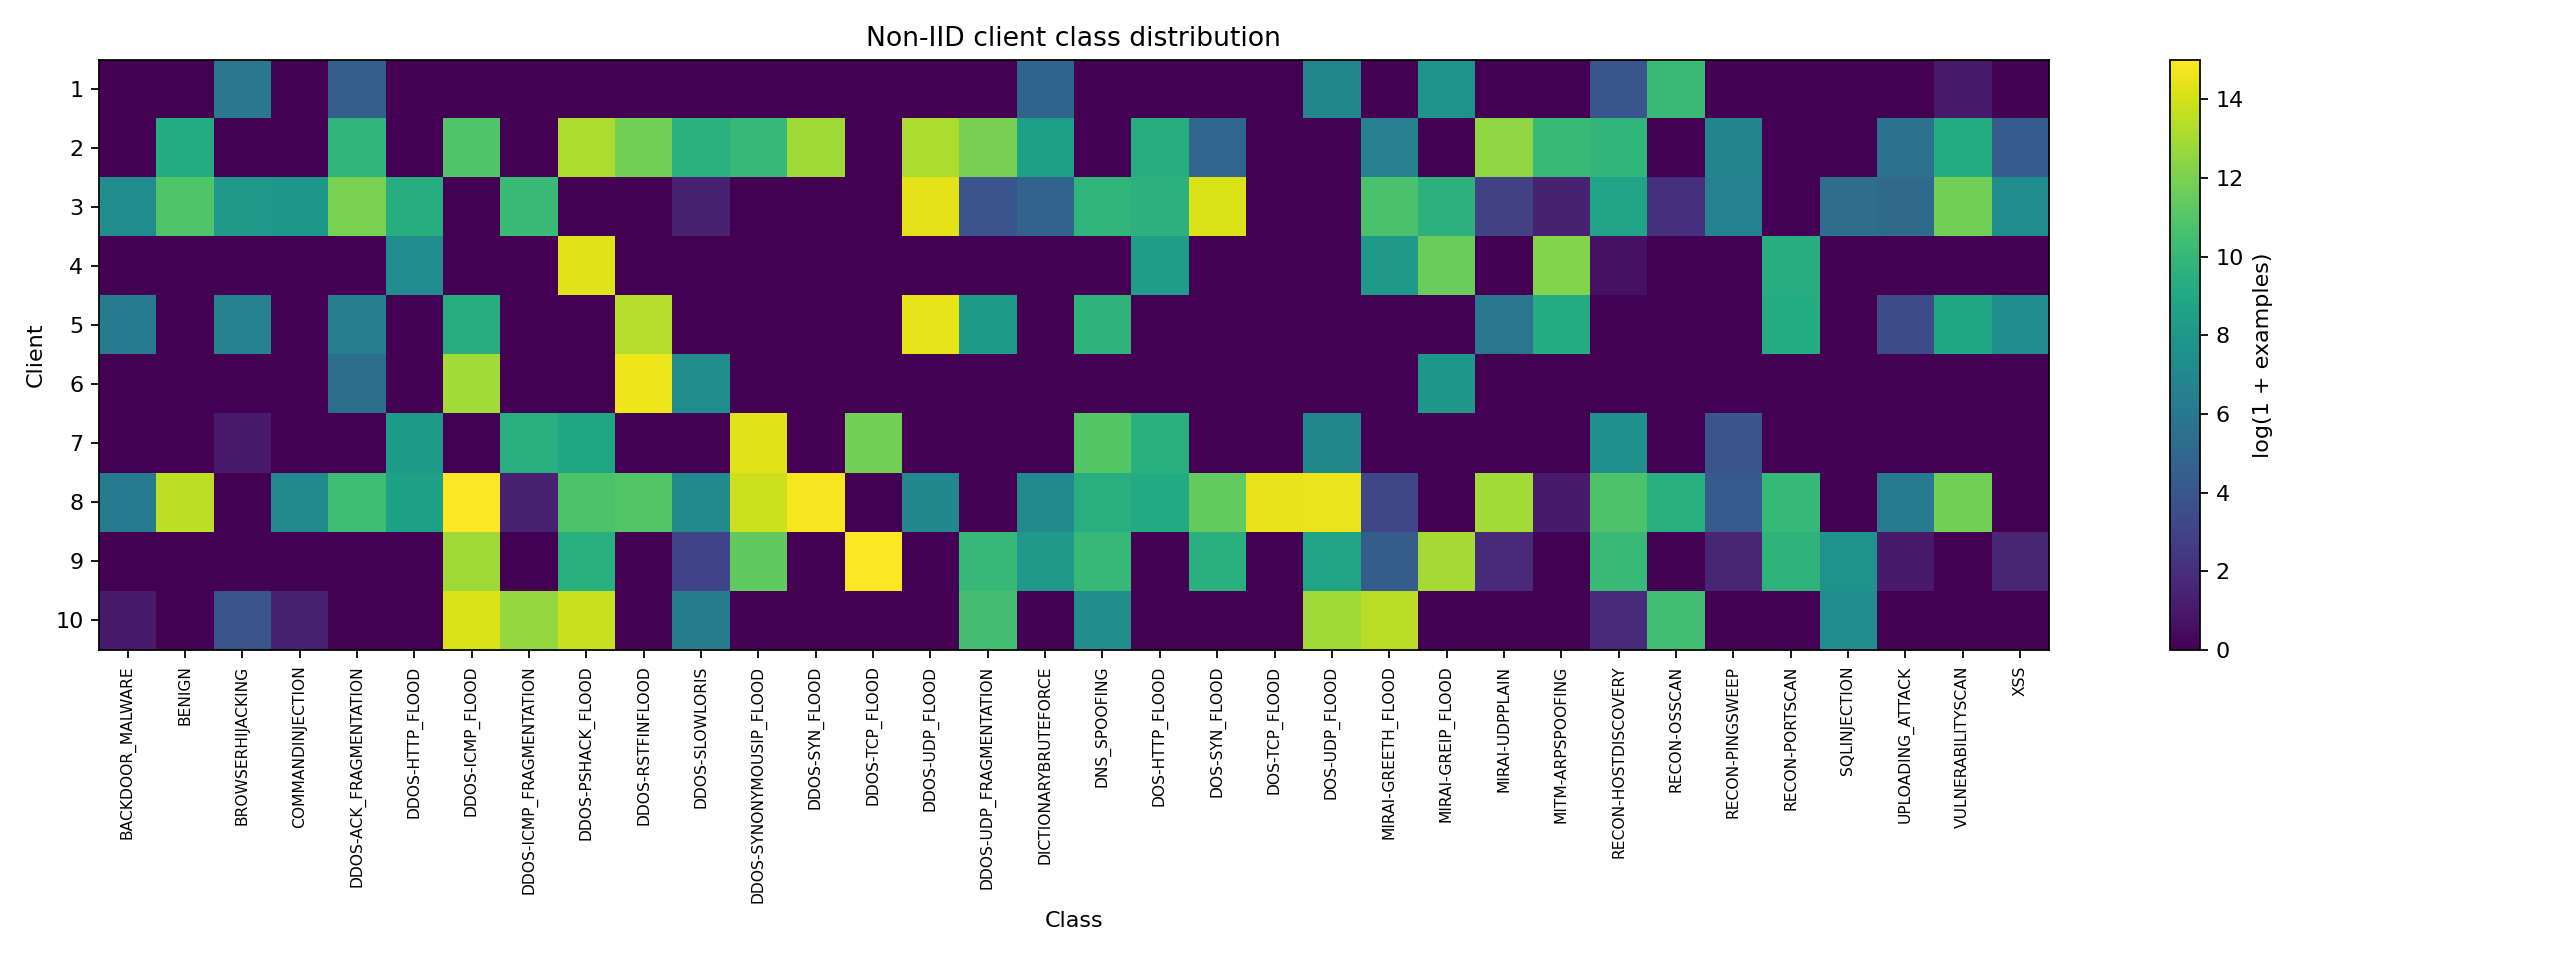

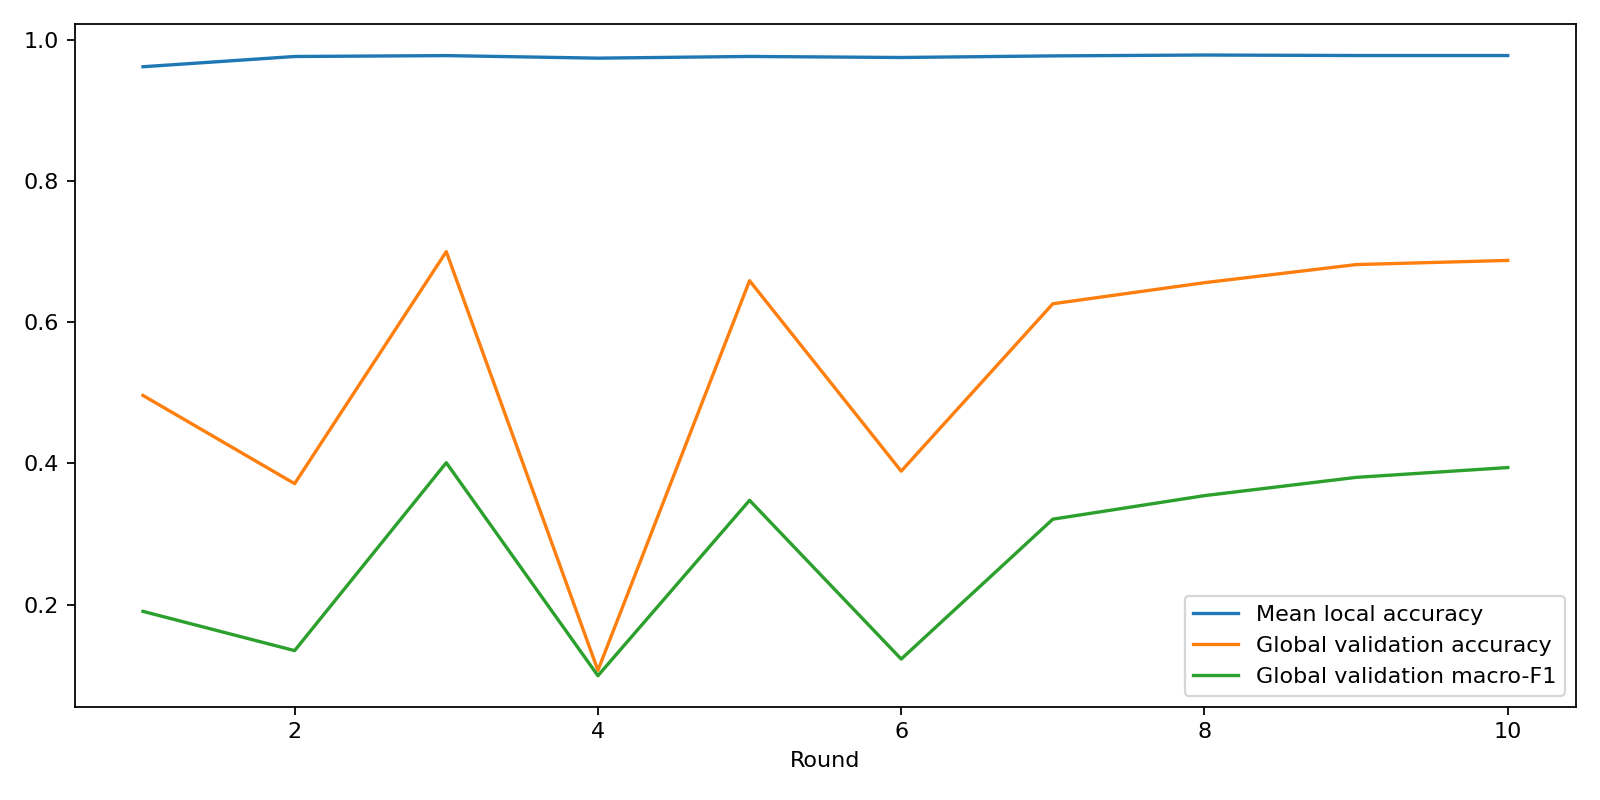

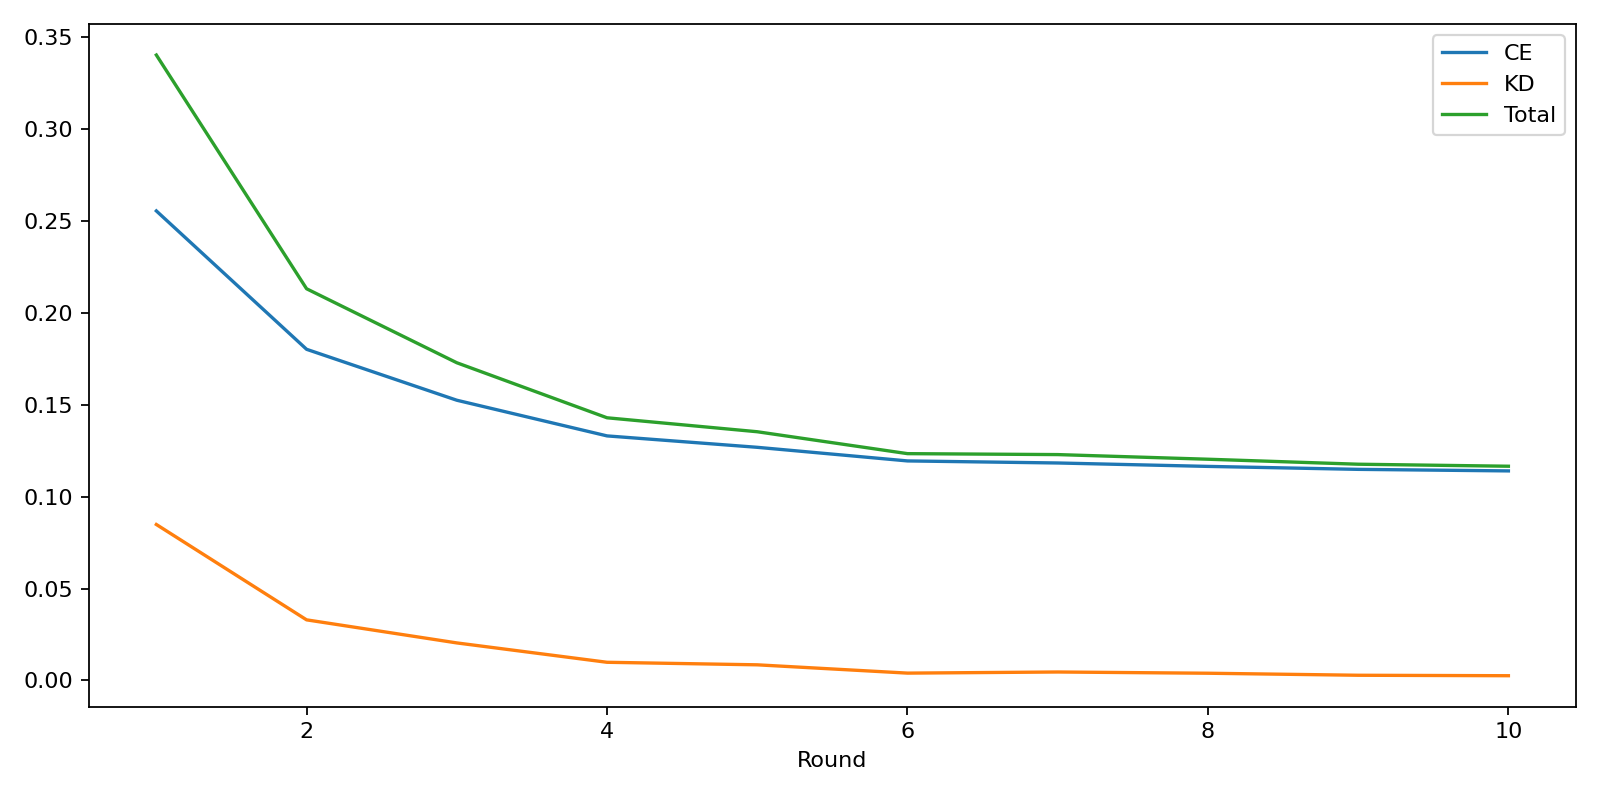

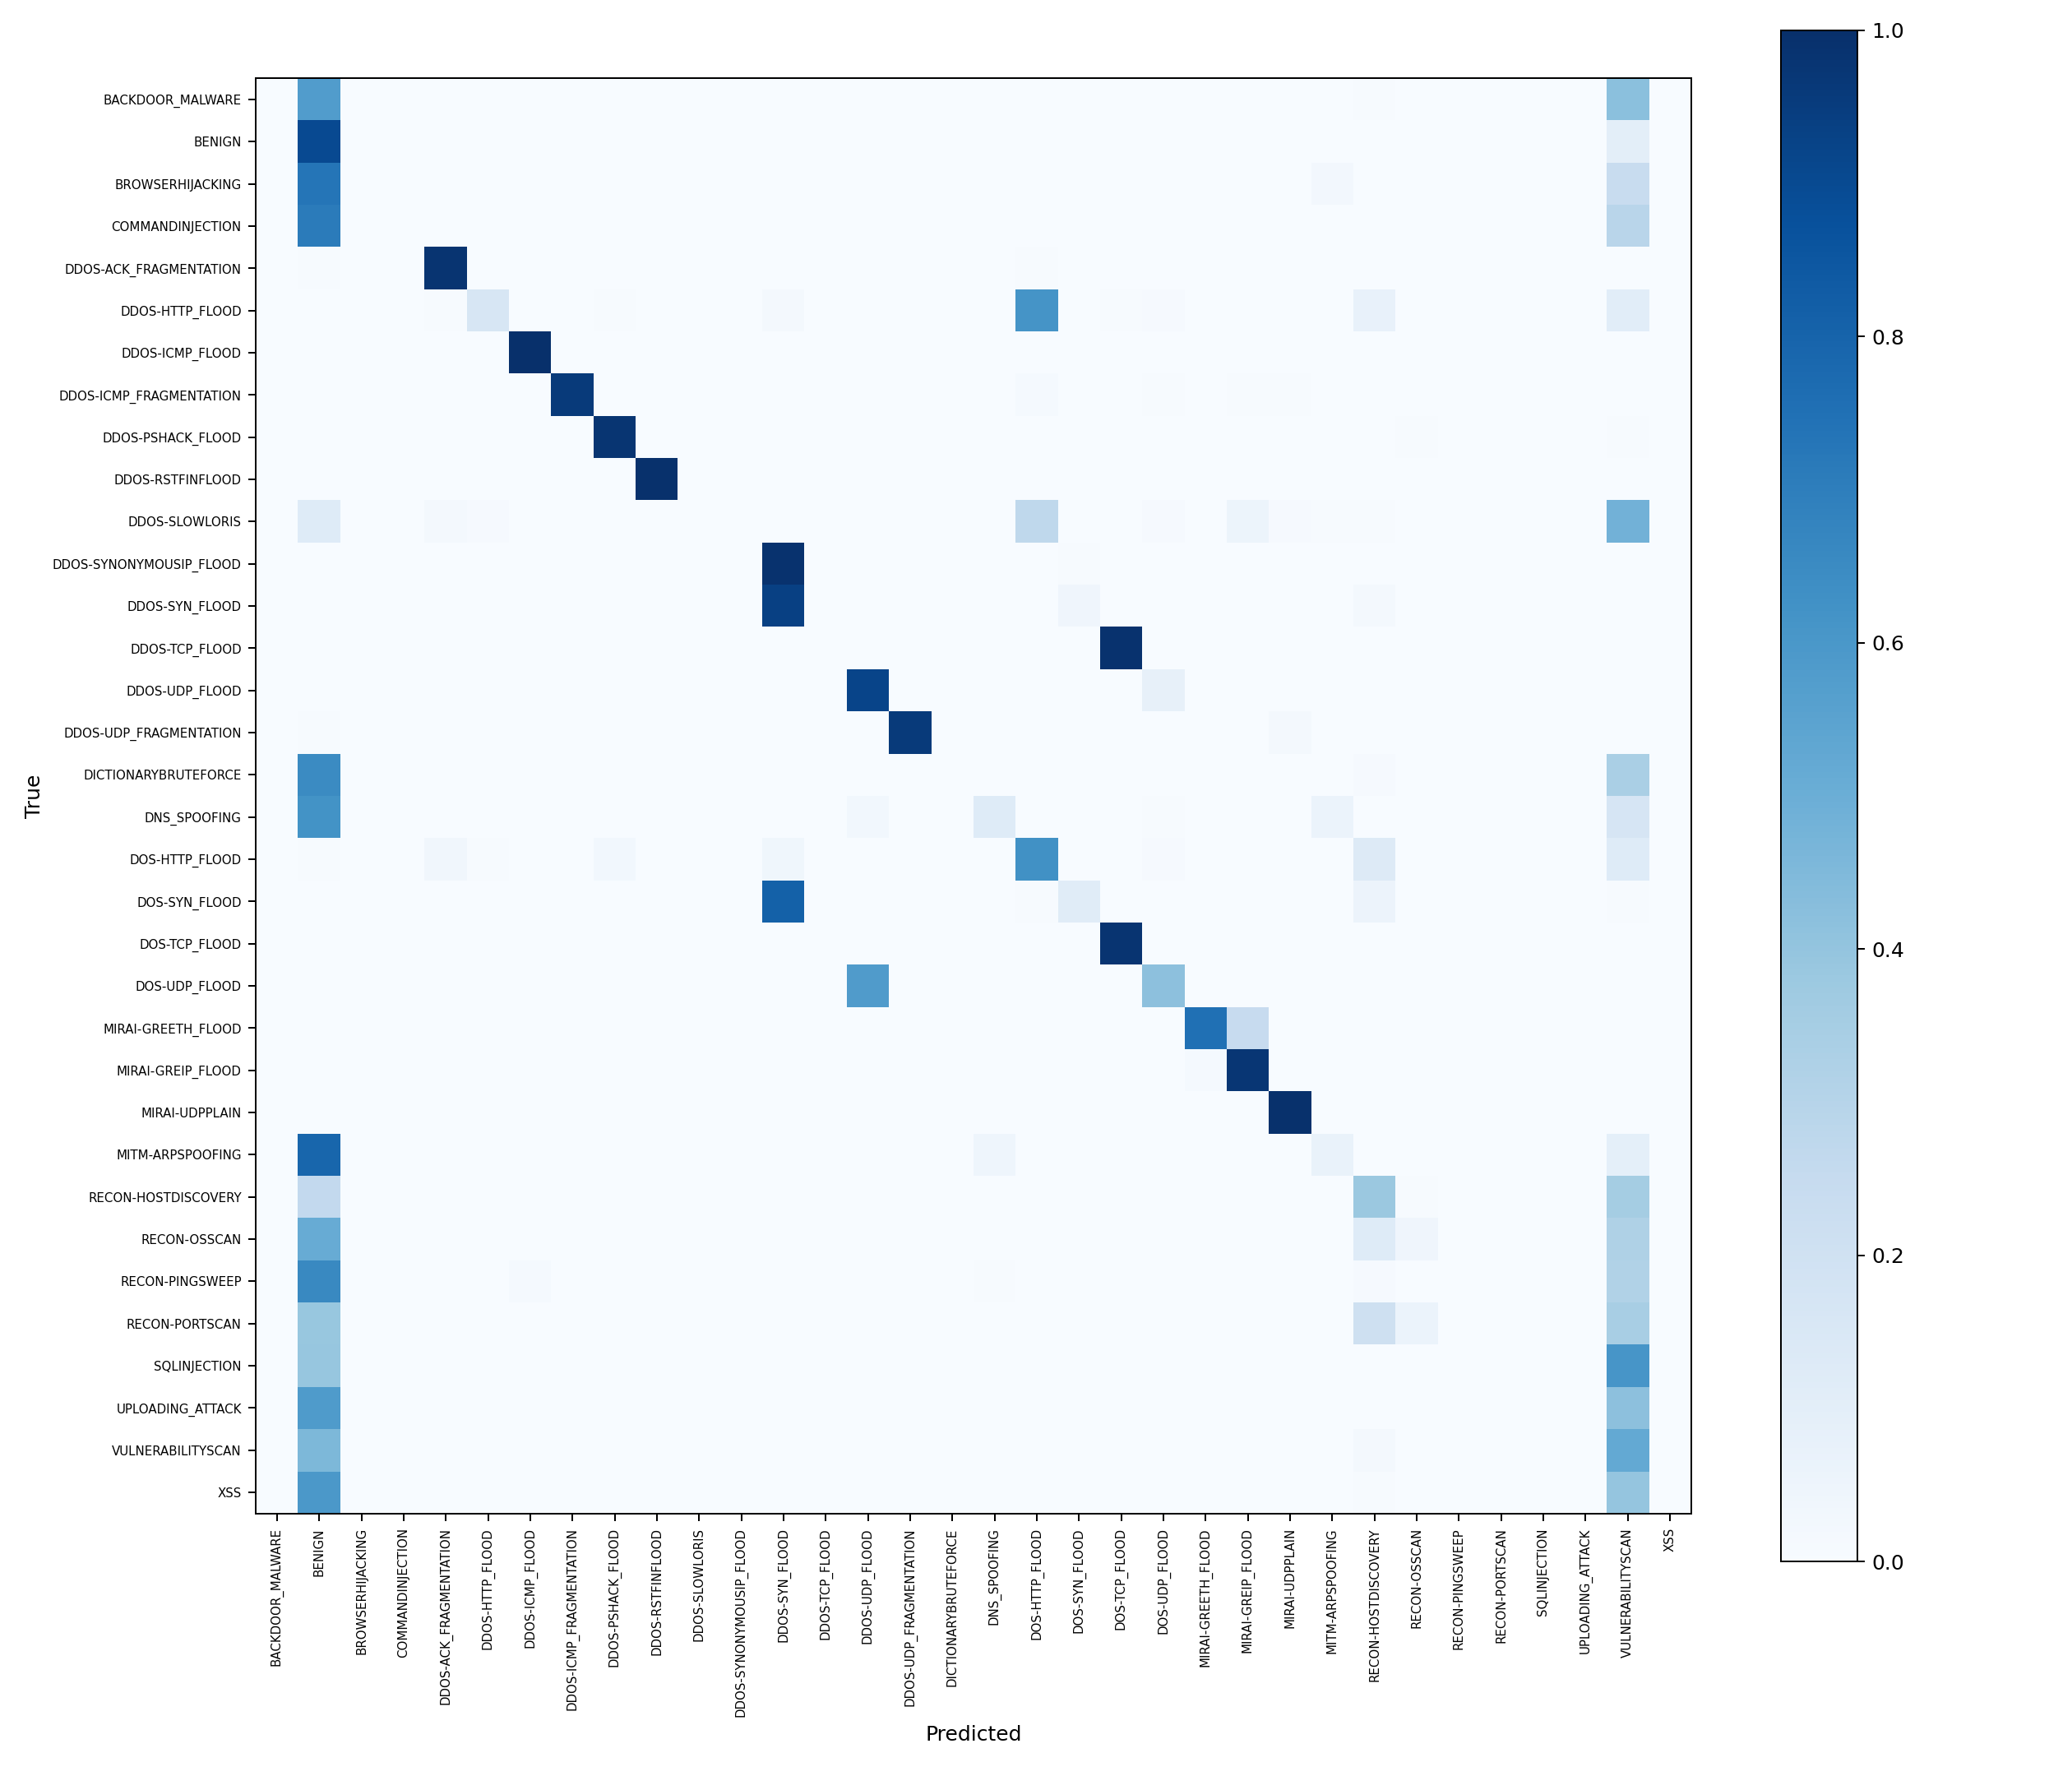

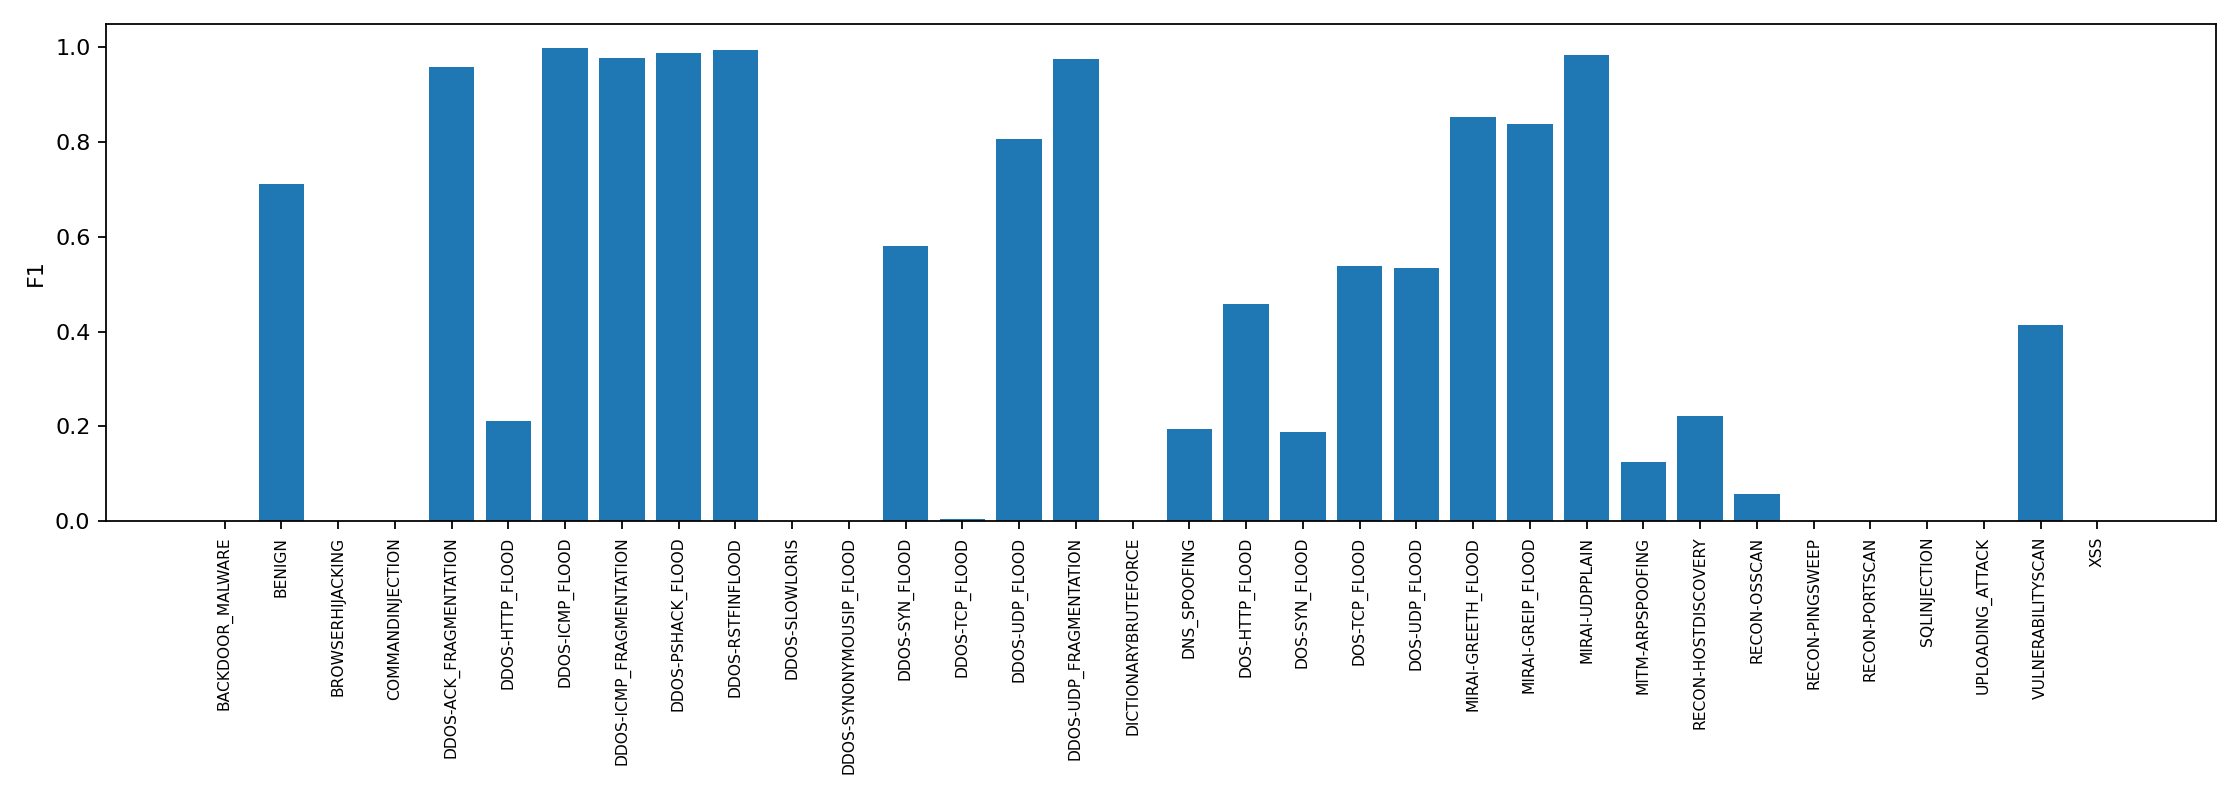

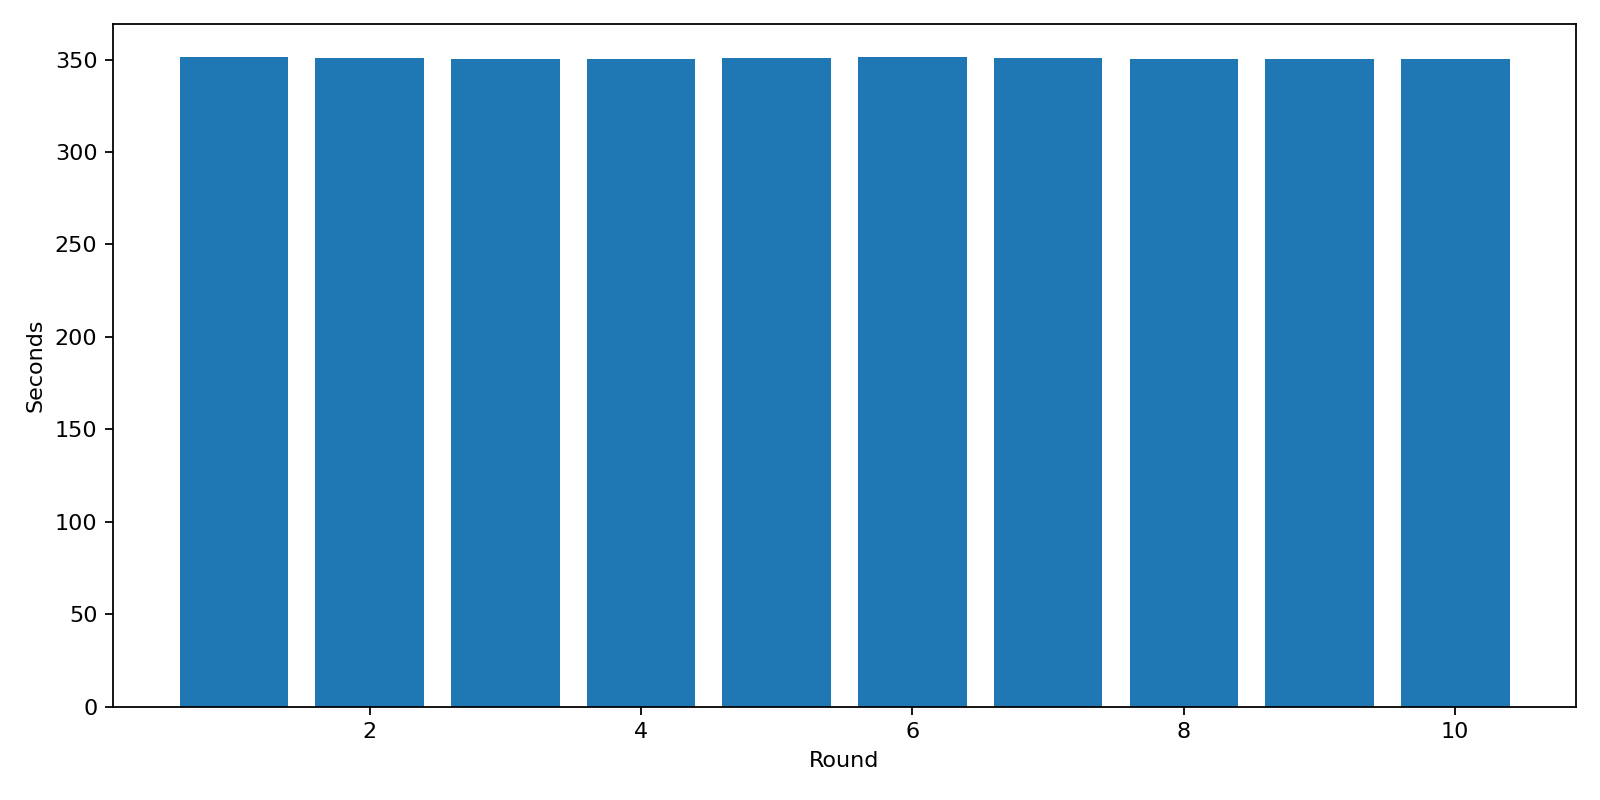

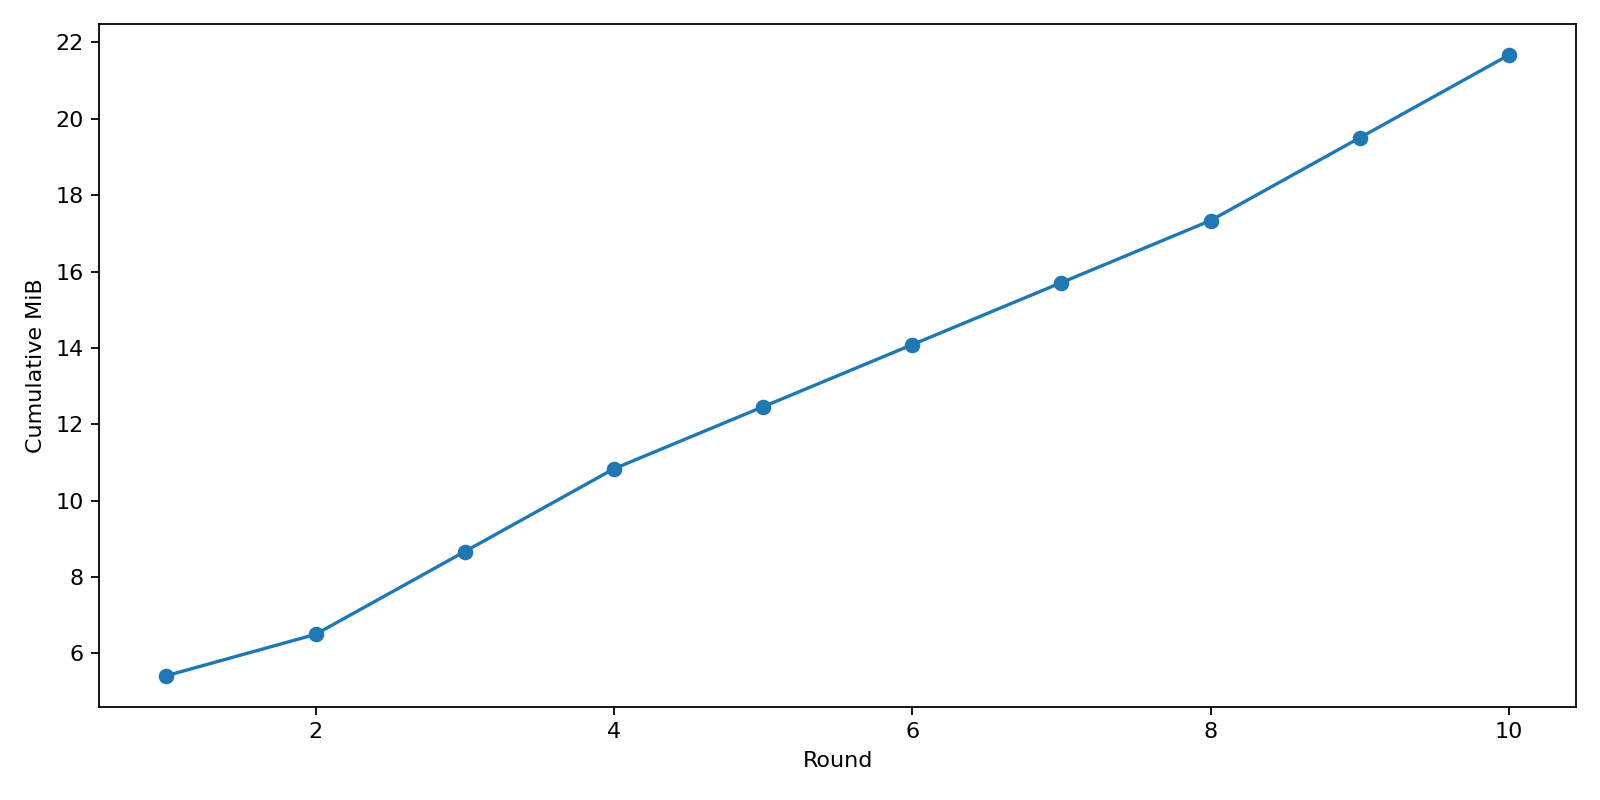

In [5]:
from IPython.display import Image, display

required_relative_paths = [
    "checkpoints/best.pt",
    "checkpoints/last.pt",
    "logs/run.log",
    "logs/rank_1.log",
    "metrics/config.json",
    "metrics/dataset_summary.json",
    "metrics/client_class_distribution.csv",
    "metrics/history_pretrain.csv",
    "metrics/history_pretrain.json",
    "metrics/history_round.csv",
    "metrics/history_round.json",
    "metrics/history_client.csv",
    "metrics/history_client.json",
    "metrics/history_local_epoch.csv",
    "metrics/history_local_epoch.json",
    "metrics/summary.json",
    "metrics/classification_report.json",
    "metrics/classification_report.csv",
    "metrics/confusion_matrix.csv",
    "metrics/confusion_matrix.npy",
    "metrics/communication_costs.json",
    "metrics/communication_costs.csv",
    "metrics/runtime_breakdown.json",
    "artifacts/class_distribution.png",
    "artifacts/accuracy_f1_curves.png",
    "artifacts/loss_curves.png",
    "artifacts/confusion_matrix.png",
    "artifacts/per_class_f1.png",
    "artifacts/runtime_per_round.png",
    "artifacts/communication_cumulative.png",
]
missing_or_empty = [
    relative
    for relative in required_relative_paths
    if not (OUTPUT_DIR / relative).is_file()
    or (OUTPUT_DIR / relative).stat().st_size == 0
]
assert not missing_or_empty, f"Missing/empty outputs: {missing_or_empty}"

history_pretrain = pd.read_csv(OUTPUT_DIR / "metrics" / "history_pretrain.csv")
history_round = pd.read_csv(OUTPUT_DIR / "metrics" / "history_round.csv")
history_client = pd.read_csv(OUTPUT_DIR / "metrics" / "history_client.csv")
history_local_epoch = pd.read_csv(
    OUTPUT_DIR / "metrics" / "history_local_epoch.csv"
)
assert len(history_pretrain) == 1
assert len(history_round) == CONFIG["communication_rounds"]
assert len(history_client) == (
    CONFIG["communication_rounds"] * CONFIG["num_clients"]
)
assert len(history_local_epoch) == (
    CONFIG["communication_rounds"] * CONFIG["num_clients"]
)
assert history_client.groupby("round")["client_id"].nunique().eq(10).all()
assert history_local_epoch["sampler_padding_rows"].eq(0).all()

with open(
    OUTPUT_DIR / "metrics" / "summary.json", "r", encoding="utf-8"
) as handle:
    final_summary = json.load(handle)
assert final_summary["status"] == "completed"
print(json.dumps(final_summary["final_global_test"], indent=2))

for artifact_name in [
    "class_distribution.png",
    "accuracy_f1_curves.png",
    "loss_curves.png",
    "confusion_matrix.png",
    "per_class_f1.png",
    "runtime_per_round.png",
    "communication_cumulative.png",
]:
    display(Image(filename=str(OUTPUT_DIR / "artifacts" / artifact_name)))
